# Introduction
Global warming has been the hot topic in the World Health Organisation (WHO) for many years. Vehicle emissions are a major source of environmental pollution and climate change, with carbon dioxide (CO2) and nitrogen oxides (NOX) being among the most significant pollutants. According to European Environment Agency (2023), CO2 has impacted the increase of temperature, while NOX emissions are associated with smog formation, acid rain, and adverse respiratory effects. Hence, the Intergovernmental Panel on Climate Change (IPCC) has suggested to closely monitor the gas emissions from the road vehicles. 

This report analyses emissions using the data from the UK Vehicle Certification Agency (VCA), which provides verified measurements of vehicle fuel consumption and emissions under the Worldwide Harmonised Light Vehicle Test Procedure (WLTP). The VCA dataset ensures consistency and accuracy across vehicle testing in accordance with European and international standards (UK Vehicle Certification Agency 2024). Through statistical and predictive modelling, this study explores the key factors influencing emission levels to support sustainable transportation research and evidence-based environmental policymaking.

In [1391]:
# Install Package 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import math

from numpy.random import normal

# Data splitting and model evaluation
from sklearn.model_selection import train_test_split, KFold, cross_val_score, learning_curve
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import  StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Exploratory Data Analysis
The data set contains of 3702 vehicles from different companies and 44 columns of measurement of vehicle types, fuel consumption and emmission. 

| Category  | Columns |
|-----------|-----------|
| Vehicle   | Manufacturer, Model, Description, Transmission, Manual or Automatic, Engine Capacity, Fuel Type, Powertrain, Engine Power (PS),  Engine Power (Kw)|
| Fuel Consumption     |   Diesel VED Supplement, Testing Scheme, WLTP Imperial Low, WLTP Imperial Medium, WLTP Imperial High, WLTP Imperial Extra High, WLTP Imperial Combined, WLTP Imperial Combined (Weighted), WLTP Metric Low, WLTP Metric Medium,  WLTP Metric High, WLTP Metric Extra High, WLTP Metric Combined, WLTP Metric Combined (Weighted) |
| Electric Consumption | Electric energy consumption Miles/kWh, wh/km ,Maximum range (Km), Maximum range (Miles), Equivalent All Electric Range Miles, Equivalent All Electric Range KM, Electric Range City Miles, Electric Range City Km |
| Standard  | Euro Standard | 
| Emmission | WLTP CO2, WLTP CO2 Weighted, Emissions CO [mg/km], THC Emissions [mg/km], Emissions NOx [mg/km], THC + NOx Emissions [mg/km], Particulates [No.] [mg/km], RDE NOx Urban, RDE NOx Combined, Noise Level dB(A) |
| Date | Date of change |


Out of the 44 columns only 9 columns which are Manufacturer, Model, Description, Transmission, Manual or Automatic, Fuel Type, Powertrain, Euro Standard, and Testing Scheme are the non-numeric data type, the rest of columns are numeric or boolean which can be used modelling. From following chart, we can see the distribution of fuel type of the vehicle in the data set. We can group the vehicles into three main categories: Fuel, Hybrid and Electric.

In [1392]:
# Loading the data
data = pd.read_csv("Euro_6_latest.csv", 
                   encoding= 'latin1') # encoding = 'latin1' is required because in the dataset, 
                                       # there are special characters. Latin1 is an encoding for Western Europe. 
data.head();
# From the data.head() code, we see that there are 45 columns. However, in this dataset, the last column is 'unnamed:44' and there is no values in this column. 
# This is because the last column in the original dataset is 'Date of change' with a comma, thus, the pandas see it as a column and include it. Thus, this last column should be slided out.
# After the initial understanding of the meaning of each column in this dataset, the first three columns 'Manufacturere', 'Model', and 'Description', 'Noise Level dB (A)'


# Moreover, from the initial assessment, as the topic focuses on the car and emission, 'Noise Level dB (A)' is not relevant and it should be also dropped. 
# Similarly, 'Date of Change' column appears simply as an updated date of each row. Hence, it is dropped.

In [1393]:
print(f"Original data shape: {data.shape}");
print(f"Data rows: {data.shape[0]}, Data columns: {data.shape[1]}");

Original data shape: (3702, 44)
Data rows: 3702, Data columns: 44


In [1394]:
data.dtypes
# only data type for column 'Date of change' is not at the right match while the rest is correct. 

Manufacturer                              object
Model                                     object
Description                               object
Transmission                              object
Manual or Automatic                       object
Engine Capacity                          float64
Fuel Type                                 object
Powertrain                                object
Engine Power (PS)                        float64
Engine Power (Kw)                        float64
Electric energy consumption Miles/kWh    float64
wh/km                                    float64
Maximum range (Km)                       float64
Maximum range (Miles)                    float64
Euro Standard                             object
Diesel VED Supplement                       bool
Testing Scheme                            object
WLTP Imperial Low                        float64
WLTP Imperial Medium                     float64
WLTP Imperial High                       float64
WLTP Imperial Extra 

In [1395]:
# Examine categorical data from Fuel Type column
fuel_type_categories = data["Fuel Type"].unique()
print(f"Unique fuel types: {fuel_type_categories}")
print(f"Number of categories: {len(fuel_type_categories)}")

Unique fuel types: ['Electricity' 'Petrol' 'Diesel' 'Electricity / Petrol' 'Petrol Electric'
 'Petrol / LPG' 'Diesel Electric' 'Electricity / Diesel']
Number of categories: 8


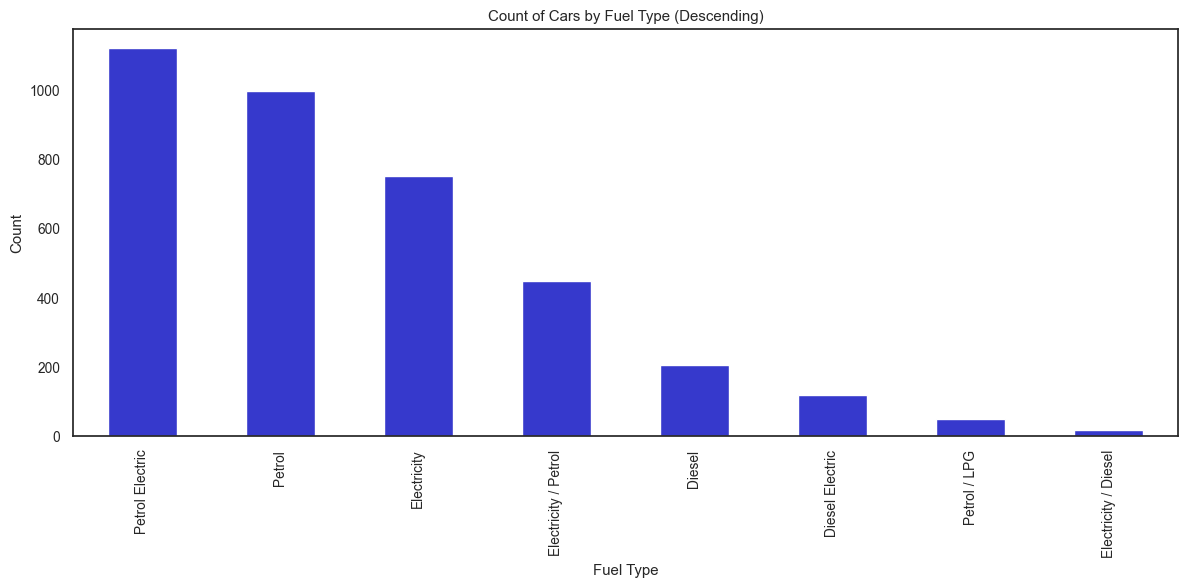

In [1396]:
# Plot the categorical data from fuel  type column
fuel_type_counts = data["Fuel Type"].value_counts().reindex(fuel_type_categories, fill_value=0)
sorted_counts = fuel_type_counts.sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sorted_counts.plot(kind="bar", color="#3639CC")
plt.title("Count of Cars by Fuel Type (Descending)")
plt.ylabel("Count")
plt.xlabel("Fuel Type")
plt.tight_layout()
plt.show()

## Emissions Analysis
As the discussion is about emission, we will further understand the different types of emissions such as Carbon Monoxide (CO), Carbon Dioxide (CO2), Nitrogen Oxides (NOx) and Total Hydrocarbons (THC). These emissions are not polluting the environment but impacting our health. According to WHO (2021), when CO binds with haemoglobin more readily than oxyegen, it might reduce oxygen transport in blood and posing serious health risks to humans. While CO2 is non-toxis to humans but it significantly contributes to global warming and climate change as it can trap the heat in the atmosphere (Intergovernmental Panel on Climate Change [IPCC], 2021). When the temperature increase, it might bring disasters to human such as flood or extreme heat wave.

### Carbon Monoxide (CO) and Carbon Dioxide (CO2)
From the following bar chart, we can clearly see the emissions of CO2 and CO are co-exists in petrol or hybrid vehicles but not in electric car. Emission of CO is high especially in diesel vehicle and emission of CO2 based on WLTP CO2 is about the same in petrol or diesel verhicles but low in hybrid vehicles. WLTP CO2 Weighted seems to be not reliable as it is empty for most of the vehicles type. 

In [1397]:
# Calculate mean emissions by fuel type
metrics_CO2 = ["WLTP CO2", "WLTP CO2 Weighted", "Emissions CO [mg/km]"]
CO2_emission_means = data.groupby("Fuel Type")[metrics_CO2].mean().reindex(fuel_type_categories)

metrics_NOx = ["Emissions NOx [mg/km]", "RDE NOx Urban", "RDE NOx Combined"]
NOx_emission_means = data.groupby("Fuel Type")[metrics_NOx].mean().reindex(fuel_type_categories)

metrics_THC = ["THC Emissions [mg/km]", "THC + NOx Emissions [mg/km]"]
has_thc = all(col in data.columns for col in metrics_THC)
THC_emission_means = (
    data.groupby("Fuel Type")[metrics_THC].mean().reindex(fuel_type_categories)
    if has_thc else None
)


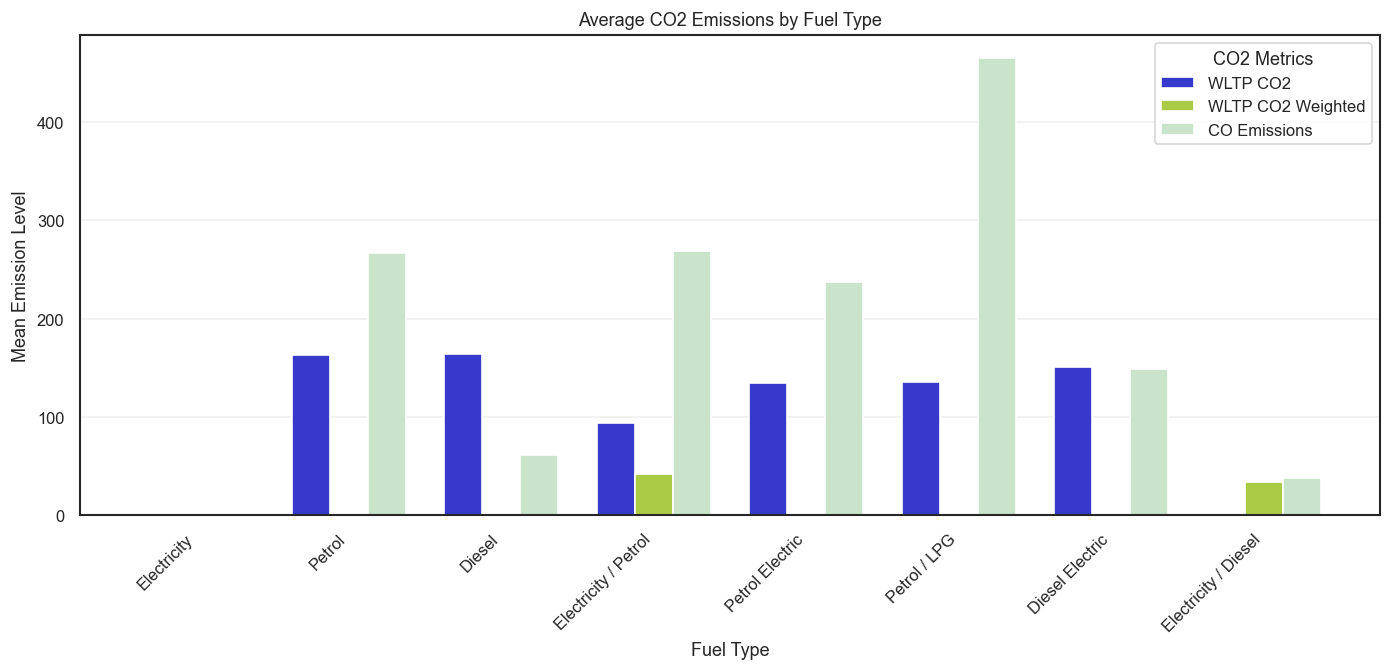

In [1398]:
# Plot average CO2 emissions by fuel type
x = np.arange(len(CO2_emission_means.index))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
ax.bar(x - width, CO2_emission_means["WLTP CO2"], width, label="WLTP CO2", color="#3639CC")
ax.bar(x, CO2_emission_means["WLTP CO2 Weighted"], width, label="WLTP CO2 Weighted", color="#ABCA45")
ax.bar(x + width, CO2_emission_means["Emissions CO [mg/km]"], width, label="CO Emissions", color="#C9E4CA")
ax.set_title("Average CO2 Emissions by Fuel Type")
ax.set_xlabel("Fuel Type")
ax.set_ylabel("Mean Emission Level")
ax.set_xticks(x)
ax.set_xticklabels(CO2_emission_means.index, rotation=45, ha="right")
ax.legend(title="CO2 Metrics")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout(pad=2.0)
plt.show()


### Nitrogen Oxides (NOx)
Nitrogen Oxides (NOx) emissions are a major cause to photochemical smog, acid rain, and respiratory health issues (U.S. Environmental Protection Agency [EPA], 2023). Based on following chart, we find NOx emission exists in all the vehicles including electic car. Electric cars do produce a small average amount of NOx according Veza et al (2023). However, it should be understood that the NOx production from electric vehicles is caused from the source of electric used to charge the car batteries. NOₓ emissions from electric vehicles originate from the fossil fuel–based electricity used to charge them. The mean for NOx in Real Driving Emissions (RDE) for urban and combined are about same but they are higher than Emissions (NOx) [mg/km] which was the result tested in lab. 

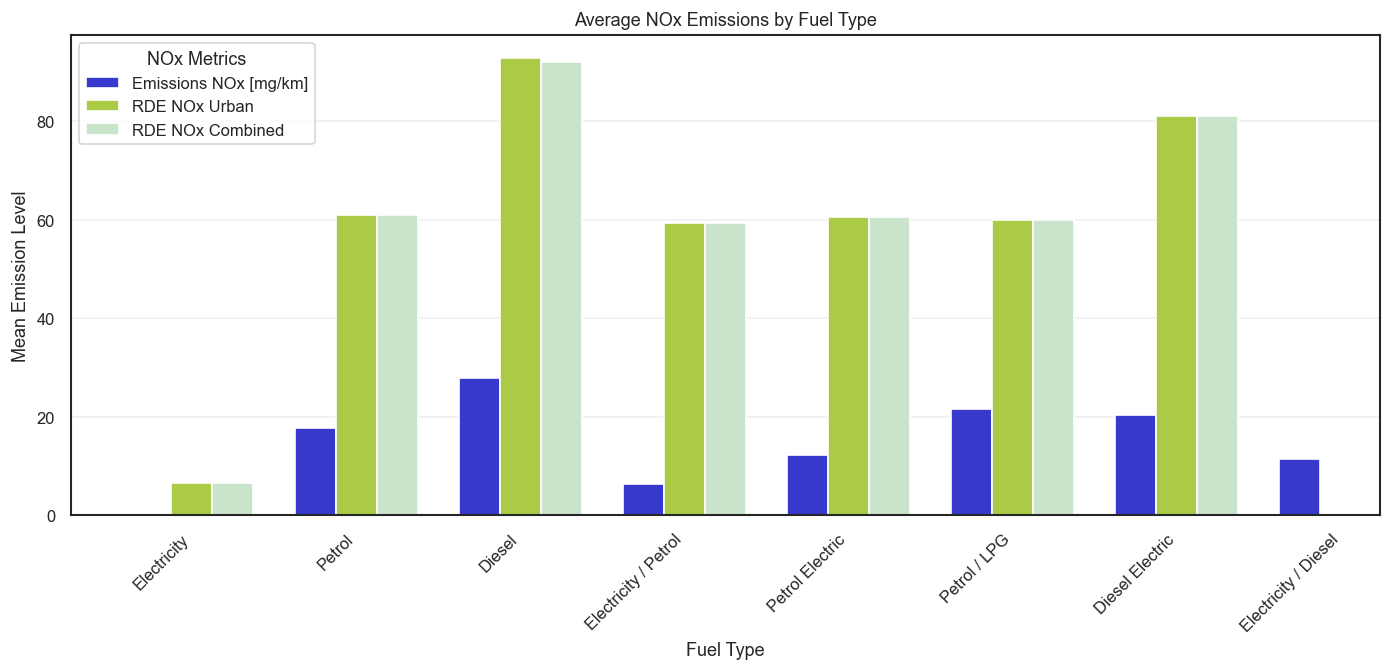

In [1399]:
# Plot average NOx emissions by fuel type
x = np.arange(len(NOx_emission_means.index))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
ax.bar(x - width, NOx_emission_means["Emissions NOx [mg/km]"], width, label="Emissions NOx [mg/km]", color="#3639CC")
ax.bar(x, NOx_emission_means["RDE NOx Urban"], width, label="RDE NOx Urban", color="#ABCA45")
ax.bar(x + width, NOx_emission_means["RDE NOx Combined"], width, label="RDE NOx Combined", color="#C9E4CA")
ax.set_title("Average NOx Emissions by Fuel Type")
ax.set_xlabel("Fuel Type")
ax.set_ylabel("Mean Emission Level")
ax.set_xticks(x)
ax.set_xticklabels(NOx_emission_means.index, rotation=45, ha="right")
ax.legend(title="NOx Metrics")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout(pad=2.0)
plt.show()


### Total Hydrocarbons (THC)
Total Hydrocarbons (THC) are volatile organic compounds (VOCs) that react with NOx in the presence of sunlight to form ground-level ozone and smog (European Environment Agency [EEA], 2022). THC might cause photochemical pollution and impact the urban air quality but it have to react with NOx, hence, in this report we will not focus in analysing the relationship of THC with other features.

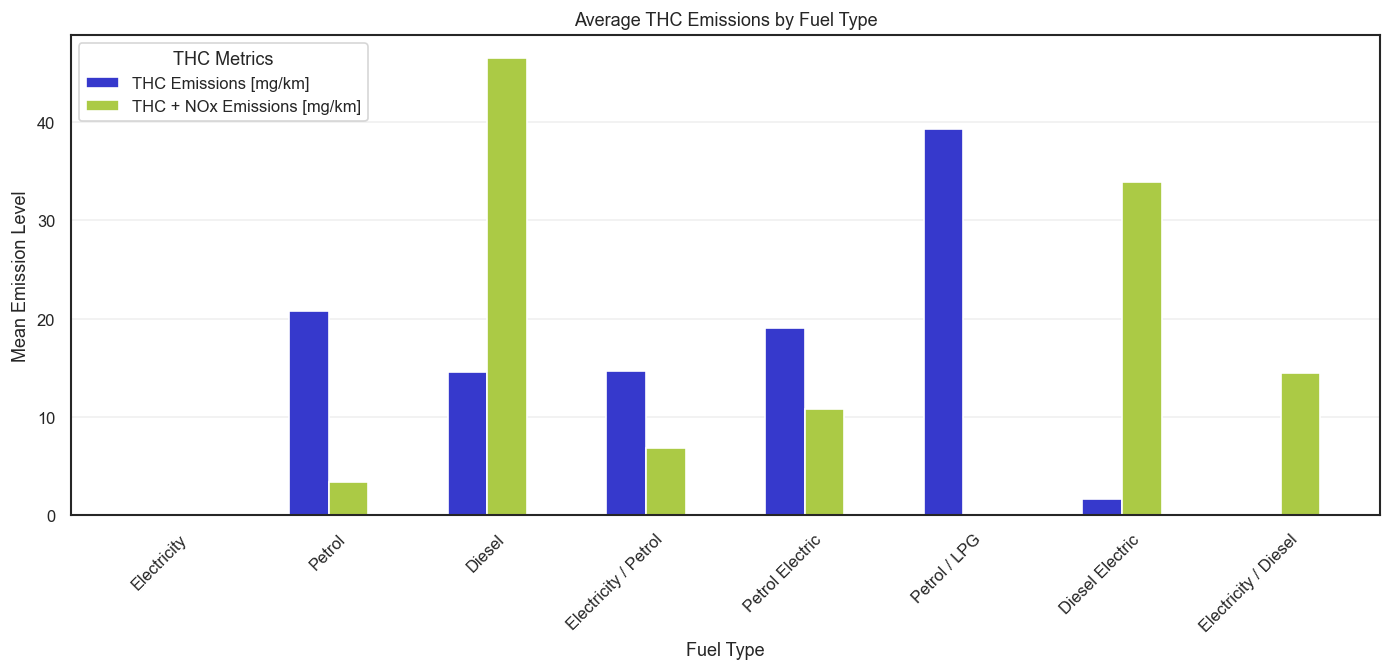

In [1400]:
# Plot average THC emissions by fuel type (if available)
if not has_thc or THC_emission_means is None:
    print("THC metrics not available for this dataset.")
else:
    x = np.arange(len(THC_emission_means.index))
    width = 0.25
    fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
    ax.bar(x - width, THC_emission_means["THC Emissions [mg/km]"], width, label="THC Emissions [mg/km]", color="#3639CC")
    ax.bar(x, THC_emission_means["THC + NOx Emissions [mg/km]"], width, label="THC + NOx Emissions [mg/km]", color="#ABCA45")
    ax.set_title("Average THC Emissions by Fuel Type")
    ax.set_xlabel("Fuel Type")
    ax.set_ylabel("Mean Emission Level")
    ax.set_xticks(x)
    ax.set_xticklabels(THC_emission_means.index, rotation=45, ha="right")
    ax.legend(title="THC Metrics")
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout(pad=2.0)
    plt.show()


## Target Variables
From the analysis, we have enough data for modelling accross different fuel types but we will choose CO2 as global warming is most common topic when discussing about the impacts of emission. As mentioned above, WLTP CO2 Weighted is lacking of data distribution accross fuel types, hence it will be excluded from target variables. Besides of CO2, we will pick Emissions NOx [mg/km] as our target variables because it has difference mean across fuld type which is easier for our comparison and prediction afterward in this report. 

Based on the graphs above, eletric cars have no CO2 emissions, and low NOx emissions. Therefore, all of the eletric cars will be excluded from the datasets when we build the model. Given the distribution, two datasets will be created based on their fuel types - fuel cars only (data_fuel), and hybrid cars only (data_hybrid). Furthermore, since the target variables (WLTP CO2 and NOx emissions) are not highly included in Eletricity /Diesel Fuel type, they will be removed from the data_hybrid.

# Data Preprocessing
## Model Building
After identified the target variables - Emissions NOx [mg/km] and WLTP CO2, based on the category that we have defined above, we will choose what are the relevant columns to keep in the modelling and remove all irrelevant columns. Reducing the variables/columns can help in improving the performance and cost effectiveness. Variables that are related to the manufacturer or car model will be removed as these variables cannot be used in predictions. As mentioned above, we will create 2 datasets - data_fuel and data_hybrid, which contains fuel vehicles and hybrid vehicles. Hence, the variables that are not relevant to fuel or hybrid will be removed too. For emmissions, we will keep only Emissions NOx [mg/km] and WLTP CO2 as our target variables and drop rest of the emissions related columns. Lastly, date and standard category columns will be removed too as this information cannot be used for modeling. 

| Category  | Keep | Remove |
|-----------|------| ------ |
| Vehicle   |  Manual or Automatic, Engine Capacity, Fuel Type, Powertrain, Engine Power (PS) | Manufacturer, Model, Description, Transmission, Engine Power (Kw) |
| Fuel Consumption | WLTP Imperial Low, WLTP Imperial Medium, WLTP Imperial High, WLTP Imperial Extra High, WLTP Imperial Combined, WLTP Imperial Combined (Weighted), WLTP Metric Low, WLTP Metric Medium,  WLTP Metric High, WLTP Metric Extra High, WLTP Metric Combined, WLTP Metric Combined (Weighted)| Diesel VED Supplement, Testing Scheme |
| Electric Consumption | |Electric energy consumption Miles/kWh, wh/km ,Maximum range (Km), Maximum range (Miles), Equivalent All Electric Range Miles, Equivalent All Electric Range KM, Electric Range City Miles, Electric Range City Km |
| Standard |  | Euro Standard | 
| Emmission | Emissions NOx [mg/km], WLTP CO2  | WLTP CO2 Weighted , THC Emissions [mg/km], THC + NOx Emissions [mg/km], Particulates [No.] [mg/km], RDE NOx Urban, RDE NOx Combined, Noise Level dB(A) |
| Date | | Date of change |

In [1401]:
removed_variables = [
    "Manufacturer", "Model", "Description",
    "Transmission", "Engine Power (Kw)", "Electric energy consumption Miles/kWh",
    "wh/km", "Maximum range (Km)", "Maximum range (Miles)",
    "Euro Standard", "Diesel VED Supplement", "Testing Scheme", 
    "WLTP CO2 Weighted", "Equivalent All Electric Range Miles", "Equivalent All Electric Range KM",
    "Electric Range City Miles", "Electric Range City Km", "Emissions CO [mg/km]",
    "THC Emissions [mg/km]", "THC + NOx Emissions [mg/km]", "Particulates [No.] [mg/km]",
    "RDE NOx Urban", "RDE NOx Combined", "Noise Level dB(A)", 
    "Date of change"
]
print(f"Data shape before removing columns: {data.shape}")
data = data.drop(columns=removed_variables)
print(f"Data shape after removing columns: {data.shape}")

Data shape before removing columns: (3702, 44)
Data shape after removing columns: (3702, 19)


After removing the irrelevant variables, we have 19 variables remained in the datasets. Next, we will split our data into two groups as mentioned above which are the hybrid vehicles and fuel vehicles. We are getting **1686 hybrid** vehicles and **1250 fuel** vehicles in our datasets after splitting by the fuel type. 

In [1402]:
# Define fuel type categories for each group
# electric_types = ["Electricity"]

hybrid_types = [
    "Electricity / Petrol", "Petrol Electric",
    "Diesel Electric"]

fuel_types = [
    "Petrol", "Diesel", "Petrol / LPG"
]

# Split the dataset
# data_electric = data[data["Fuel Type"].isin(electric_types)] #Can remove since not relevant to the target variable
data_hybrid = data[data["Fuel Type"].isin(hybrid_types)]
data_fuel = data[data["Fuel Type"].isin(fuel_types)]

# print(f"Electric cars: {data_electric.shape[0]} rows")
print(f"Hybrid cars: {data_hybrid.shape[0]} rows")
print(f"Fuel cars: {data_fuel.shape[0]} rows")
# print(f"Original data: {data.shape[0]} rows ") #To check whether the split is correct

Hybrid cars: 1686 rows
Fuel cars: 1250 rows


## Data Cleaning
Before we start the modelling, cross checking on the data with "not available (NA)" values or empty, this will help to ensure the accuracy of our model. Based on the result, we found NA values in WLTP Imperial Combined (Weighted) and WLTP Metric Combined (Weighted) columns in both fuel and hybrid datasets. After removing the NA rows, we have **1233 fuel** vehicles and **1683 hybrid** vehicles remained in the datasets. 

In [1403]:
print("Fuel dataset shape before removing NA values:", data_fuel.shape);
print("Hybrid dataset shape before removing NA values:", data_hybrid.shape);

Fuel dataset shape before removing NA values: (1250, 19)
Hybrid dataset shape before removing NA values: (1686, 19)


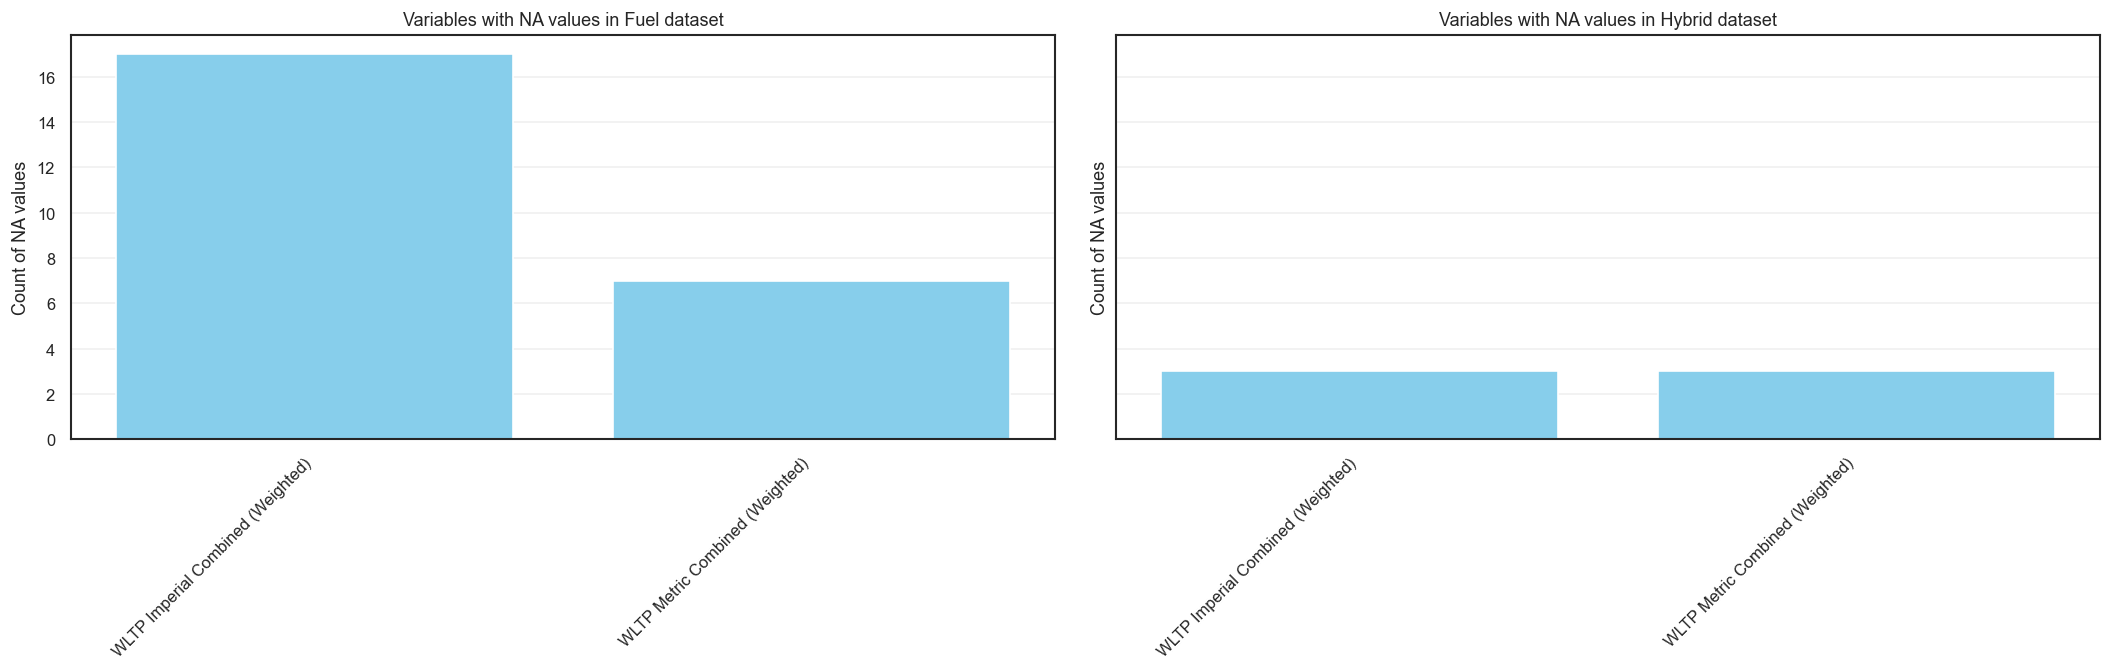

In [1404]:
# Visualise columns containing NA values
def count_visualisa_na(data, data_name="data", *, compare_data=None, compare_name=None):
    def _prepare_counts(df):
        counts = df.isna().sum()
        counts = counts[counts > 0]
        return counts

    counts_main = _prepare_counts(data)

    if compare_data is None:
        if counts_main.empty:
            print(f"No NA values found in {data_name}.")
            return
        fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
        positions = np.arange(len(counts_main))
        ax.bar(positions, counts_main.values, color="skyblue")
        ax.set_xticks(positions)
        ax.set_xticklabels(counts_main.index, rotation=45, ha="right")
        ax.set_ylabel("Count of NA values")
        ax.set_title(f"Variables with NA values in {data_name}")
        ax.grid(axis="y", alpha=0.3)
        fig.tight_layout(pad=2.0)
        plt.show()
        return

    compare_name = compare_name or "comparison dataset"
    counts_compare = _prepare_counts(compare_data)

    if counts_main.empty and counts_compare.empty:
        print(f"No NA values in either {data_name} or {compare_name}.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(18, 6), dpi=120, sharey=True)
    configs = [
        (axes[0], counts_main, f"Variables with NA values in {data_name}"),
        (axes[1], counts_compare, f"Variables with NA values in {compare_name}")
    ]

    for ax, counts, title in configs:
        if counts.empty:
            ax.axis("off")
            ax.set_title(title)
            ax.text(0.5, 0.5, "No NA values", ha="center", va="center", fontsize=12, transform=ax.transAxes)
            continue
        positions = np.arange(len(counts))
        ax.bar(positions, counts.values, color="skyblue")
        ax.set_xticks(positions)
        ax.set_xticklabels(counts.index, rotation=45, ha="right")
        ax.set_ylabel("Count of NA values")
        ax.set_title(title)
        ax.grid(axis="y", alpha=0.3)

    fig.tight_layout(pad=2.0)
    plt.show()

if "data_hybrid" in globals():
    count_visualisa_na(
        data_fuel,
        data_name="Fuel dataset",
        compare_data=data_hybrid,
        compare_name="Hybrid dataset"
    )
else:
    count_visualisa_na(data_fuel, data_name="Fuel dataset")


In [1405]:
data_fuel = data_fuel.dropna()
print("Dataset shape after removing NA values:", data_fuel.shape)


Dataset shape after removing NA values: (1233, 19)


In [1406]:
data_hybrid = data_hybrid.dropna()
print("Dataset shape after removing NA values:", data_hybrid.shape)

Dataset shape after removing NA values: (1683, 19)


## Correlation Analysis
Correlation analysis started with a heatmap to understand the correlation between each variables. From the heatmap, we can see the correlation with our target variables are low at Engine Power (Ps), WLTP Imperial Combined (Weighted), and WLTP Metric Combined (Weighted). 

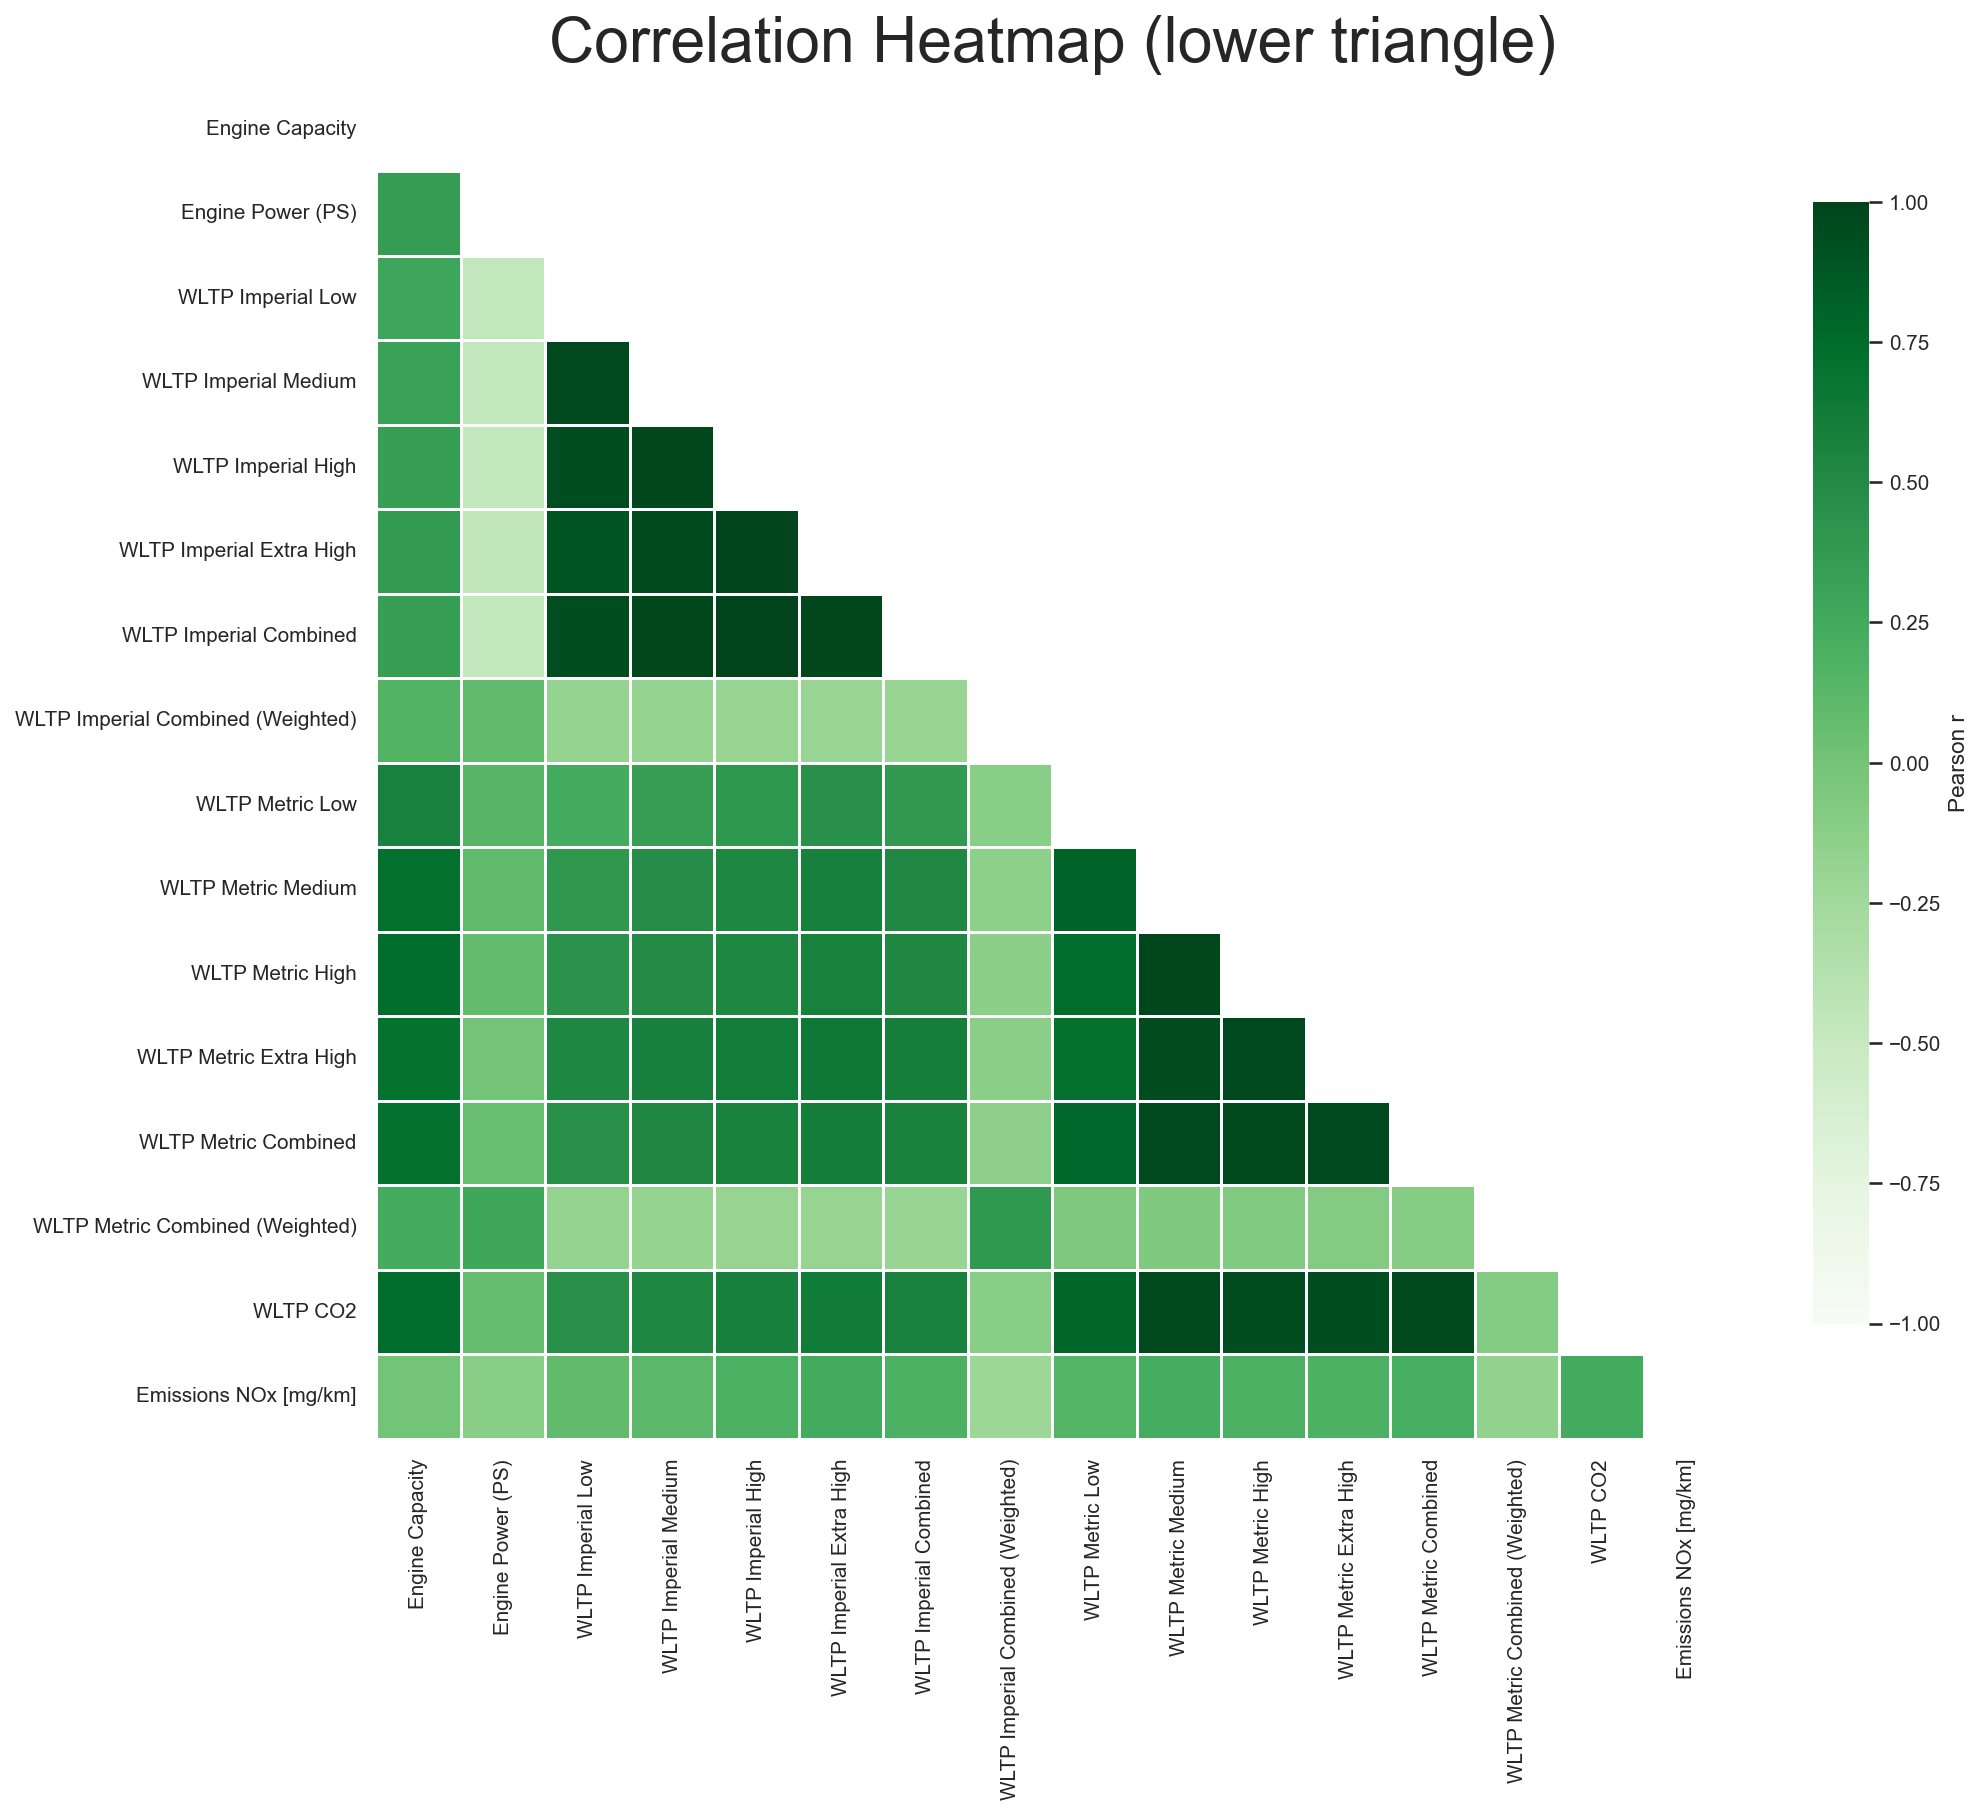

In [1407]:
sns.set_theme(style="white", font_scale=0.9)  # smaller fonts

# Select only numeric columns for computing correlation
numeric_data = data.select_dtypes(include=[np.number])
corr = numeric_data.corr()

# mask the upper triangle (matrix is symmetric)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 12), dpi=150)
ax = sns.heatmap(
    corr, mask=mask, cmap="Greens", vmin=-1, vmax=1, center=0,
    linewidths=.5, linecolor="white",
    cbar_kws=dict(shrink=.8, label="Pearson r"),
    annot=False,  # turn off numbers (too dense)
    square=True
)

ax.set_title("Correlation Heatmap (lower triangle)", fontsize = 30, pad=12)
plt.tight_layout()
plt.show()

In [1408]:
# Create a function to plot top Correlation values based on the target variable
def plot_top_correlation(variable: str, data, *, compare_data=None, compare_name=None):
    """Plot correlations for `variable` in `data`.

    When `compare_data` is provided, render a side-by-side subplot for comparison.
    """

    def _compute_top(df):
        if variable not in df.columns:
            raise KeyError(f"{variable} not found in dataframe columns")
        corr = df.select_dtypes(include="number").corr()
        if variable not in corr.columns:
            raise ValueError(f"{variable} is not numeric or lacks correlations")
        series = corr[variable].drop(labels=[variable])
        return series.reindex(series.abs().sort_values(ascending=False).index).head(20)

    def _infer_label(df, explicit=None):
        if explicit:
            return explicit
        if "Fuel Type" in df.columns:
            if df["Fuel Type"].isin(fuel_types).any():
                return "Fuel Cars"
            if df["Fuel Type"].isin(hybrid_types).any():
                return "Hybrid Cars"
        return "Dataset"

    def _plot(ax, series, title):
        bars = ax.barh(series.index, series.values, color="seagreen", edgecolor="black")
        for bar, value in zip(bars, series.values):
            ax.text(value, bar.get_y() + bar.get_height() / 2, f"{value:.2f}",
                    ha="left" if value > 0 else "right", va="center", fontsize=9)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title(title, fontsize=15, pad=10)
        ax.set_xlabel("Correlation - Pearson r", fontsize=11)
        ax.set_ylabel("Variable", fontsize=11)
        ax.invert_yaxis()
        ax.grid(axis="x", alpha=0.3)

    primary_label = _infer_label(data)
    top_primary = _compute_top(data)

    if compare_data is None:
        fig, ax = plt.subplots(figsize=(8, 7), dpi=150)
        _plot(ax, top_primary, f"Correlations with {variable} from {primary_label}")
        fig.tight_layout()
        plt.show()
        return

    secondary_label = _infer_label(compare_data, explicit=compare_name)
    top_secondary = _compute_top(compare_data)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=150, sharey=False)
    _plot(axes[0], top_primary, f"Correlations with {variable} from {primary_label}")
    _plot(axes[1], top_secondary, f"Correlations with {variable} from {secondary_label}")
    axes[1].set_ylabel("")
    fig.tight_layout()
    plt.show()



When drilling down to the correlations with CO2, we can see that the WLTP Imperial Combined (Weighted) and WLTP Metric Combined (Weighted) are having the lowest score in both fuel and hybrid vehicles. Whereas fuel is having high correlation with fuel vehicle but not the hybrid vehicle. 

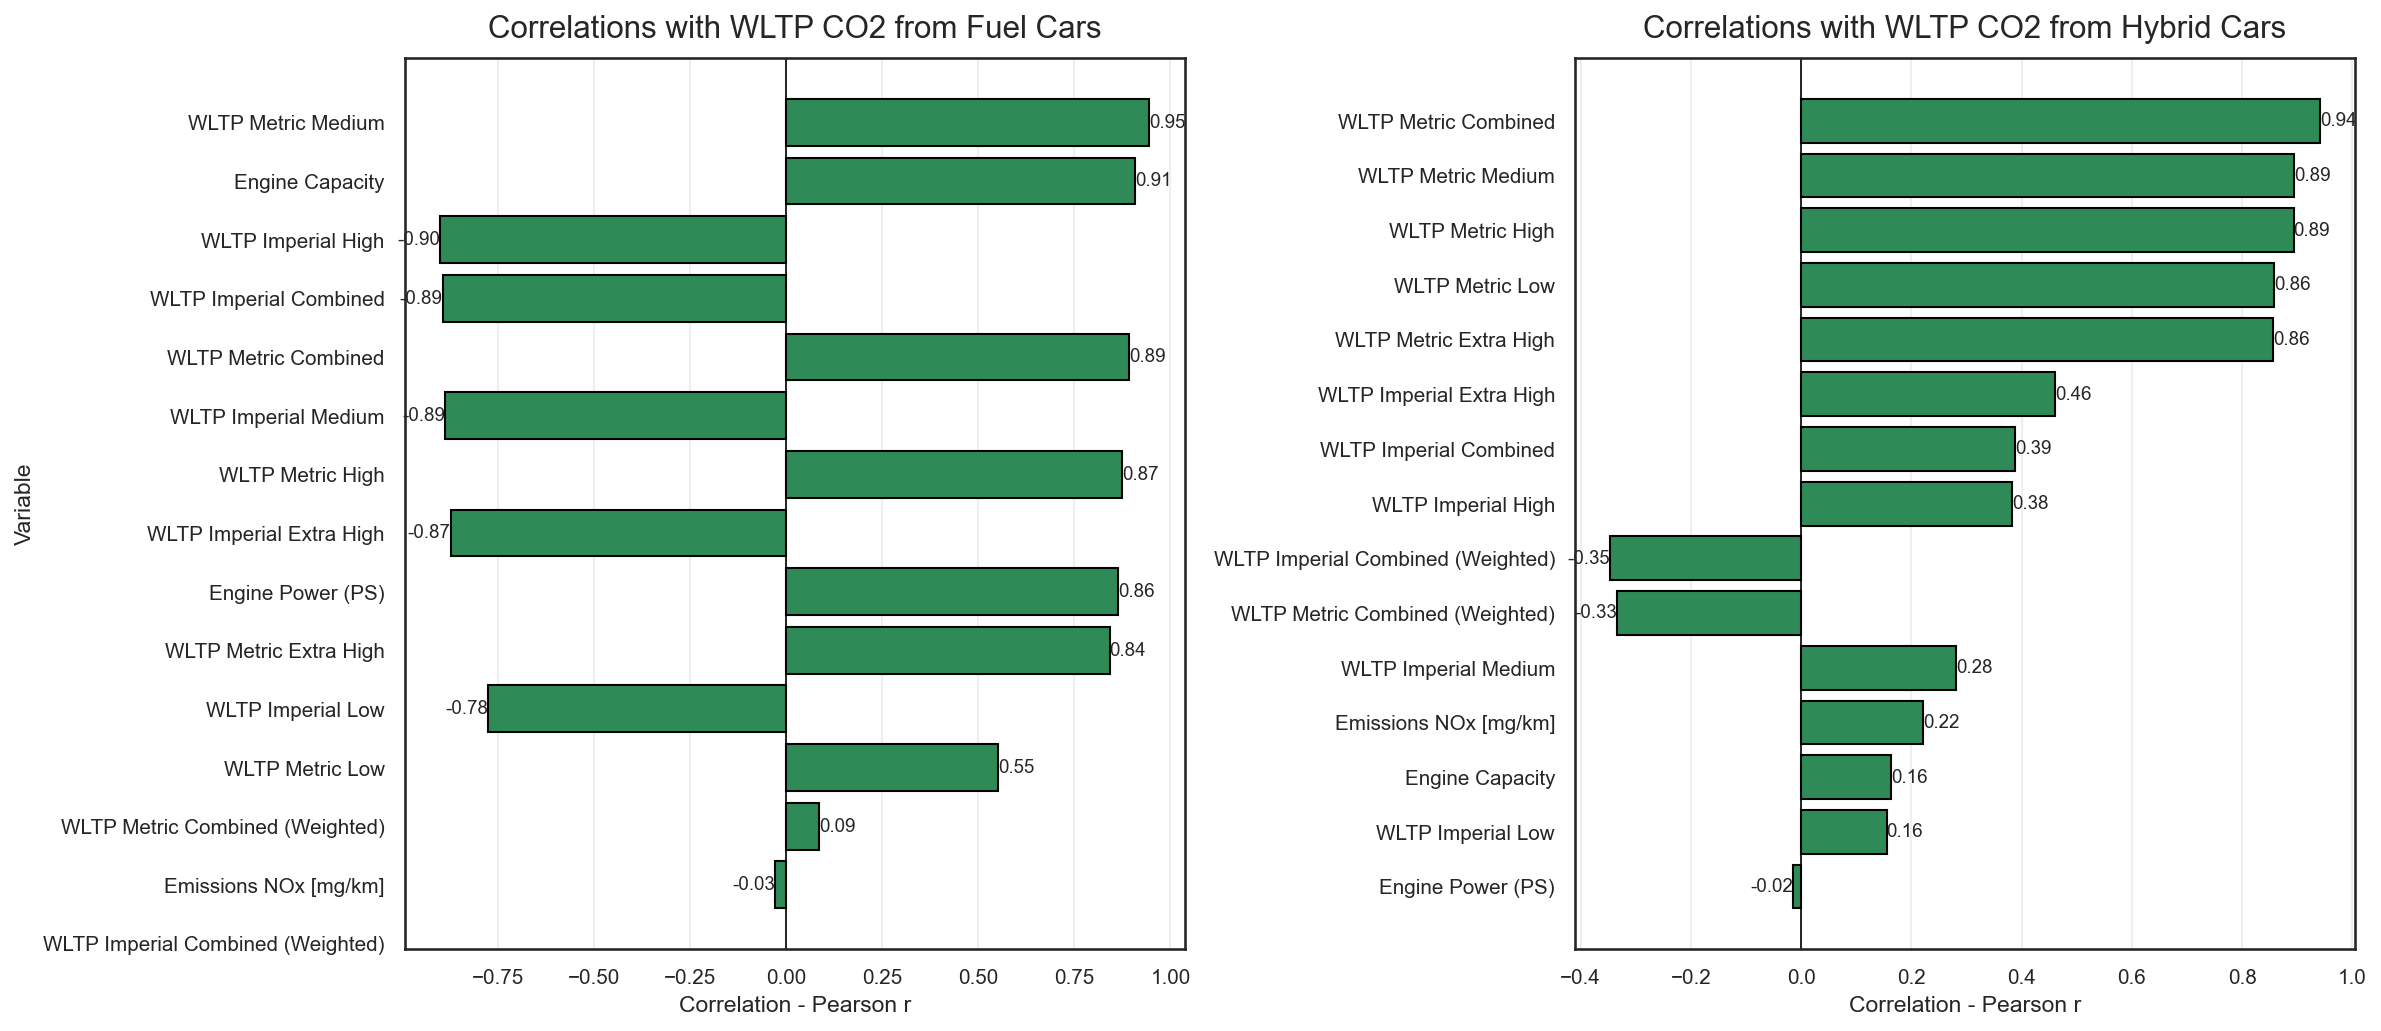

In [1409]:
# -- Correlation comparison: Fuel
plot_top_correlation("WLTP CO2", data_fuel, compare_data=data_hybrid, compare_name="Hybrid Cars")

In NOx emmissions, WLTP Imperial Combined (Weighted) and WLTP Metric Combined (Weighted) are still having lowest correlation in fuel vehicles but these variables are the top three correlated variables in hybrid vehicles. This could be due to the hybrid engine turns on intermittently, it often operates under non-steady, high-load conditions to recharge the battery or accelerate. 

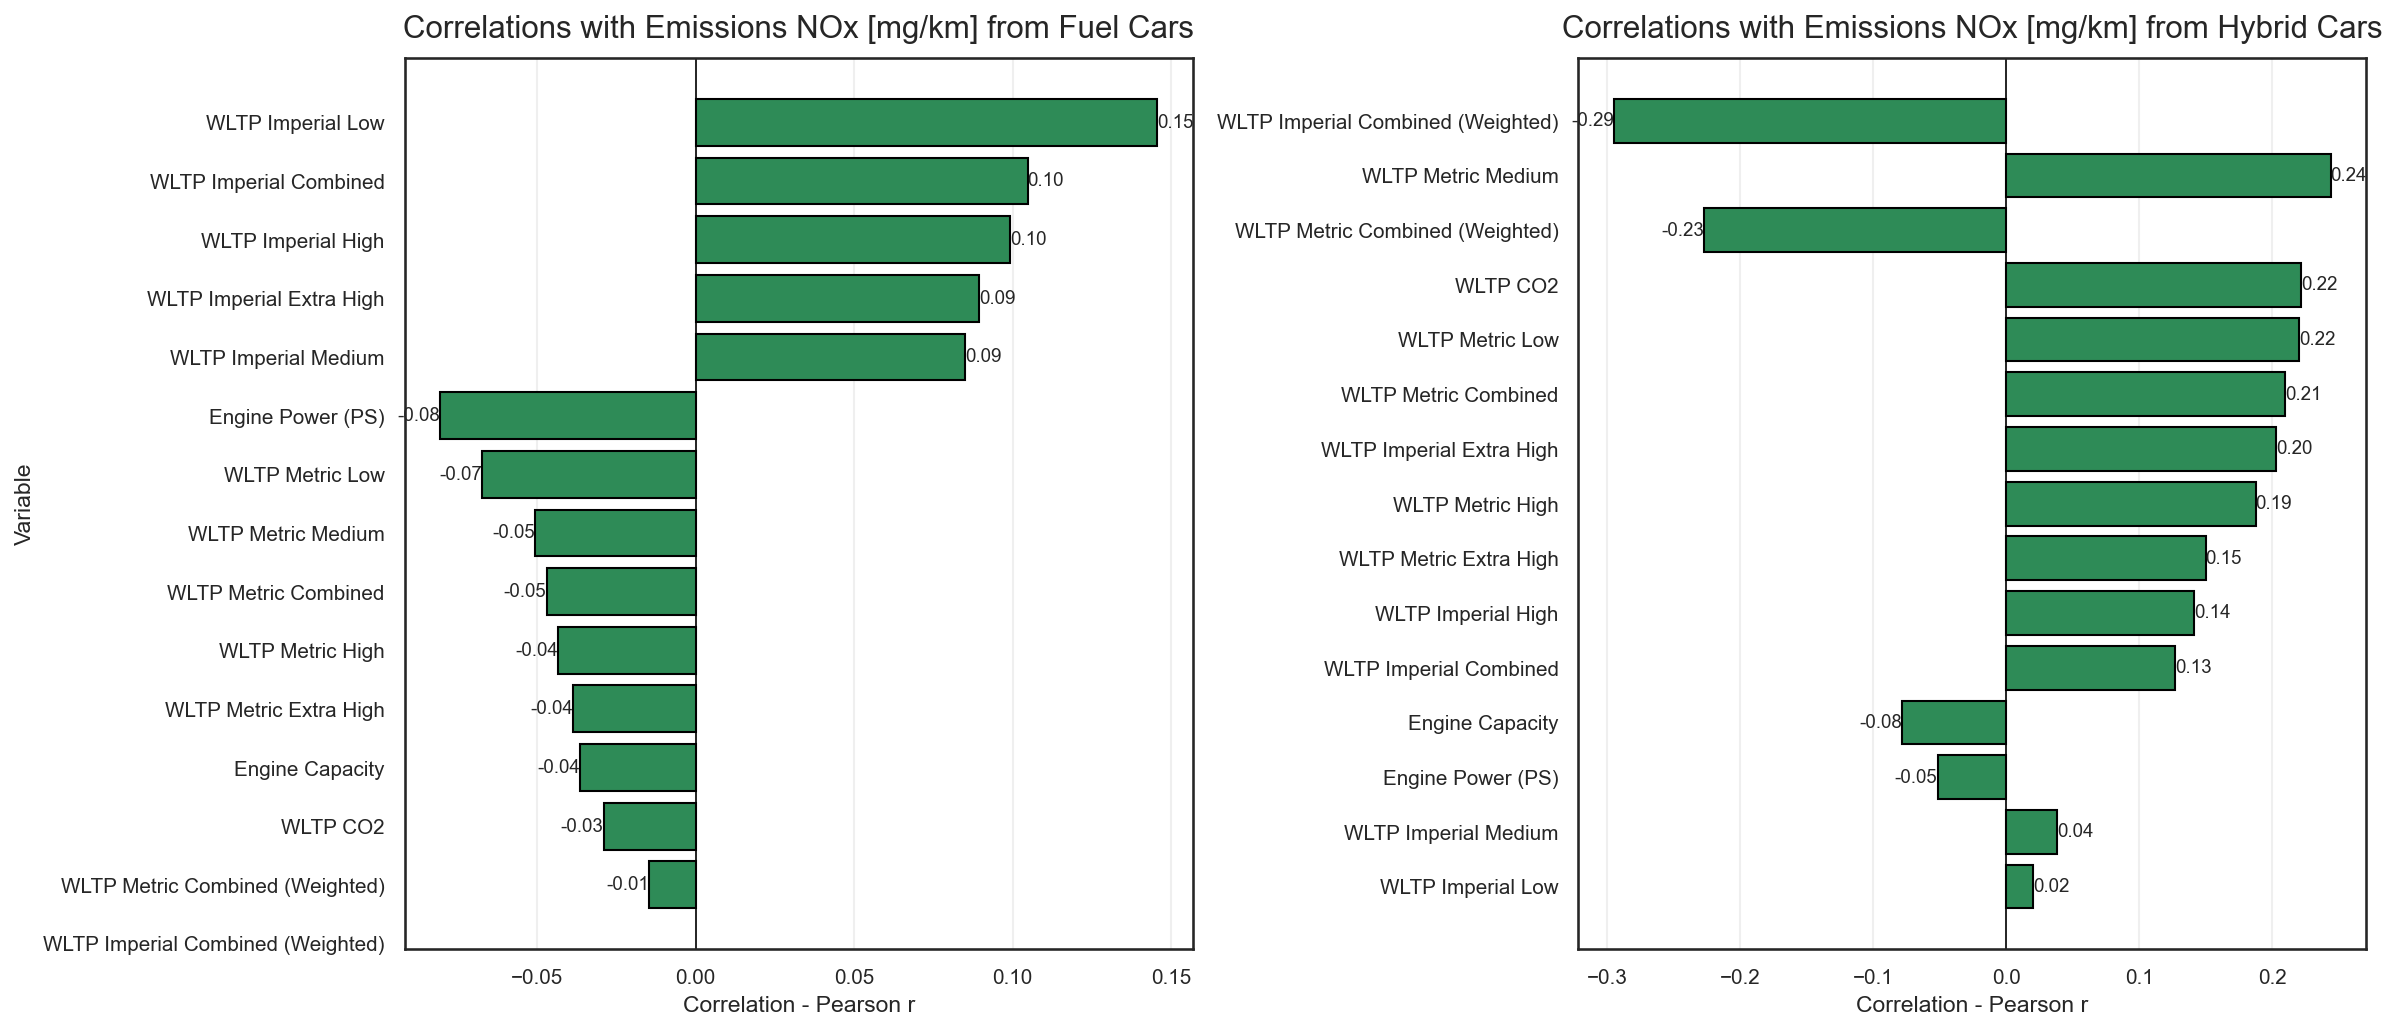

In [1410]:
# -- Correlation comparison: Hybrid
plot_top_correlation("Emissions NOx [mg/km]", data_fuel, compare_data=data_hybrid, compare_name="Hybrid Cars")

## Data Distribution Analysis
Distribution of data is important in identifying the normalisation or standardisation of each variables in our datasets. Below histogram matrix that showing the data distribution for fuel vehicles, we can see that WLTP Imperial Combined (Weighted) and WLTP Metric Combined (Weighted) are not statistically normalised, as their disbutions are tightly clustered and do not follow a standardisation or z-score normalisation. Hence, we can safely remove WLTP Imperial Combined (Weighted) and WLTP Metric Combined (Weighted) columns from _data_fuel_ dataset

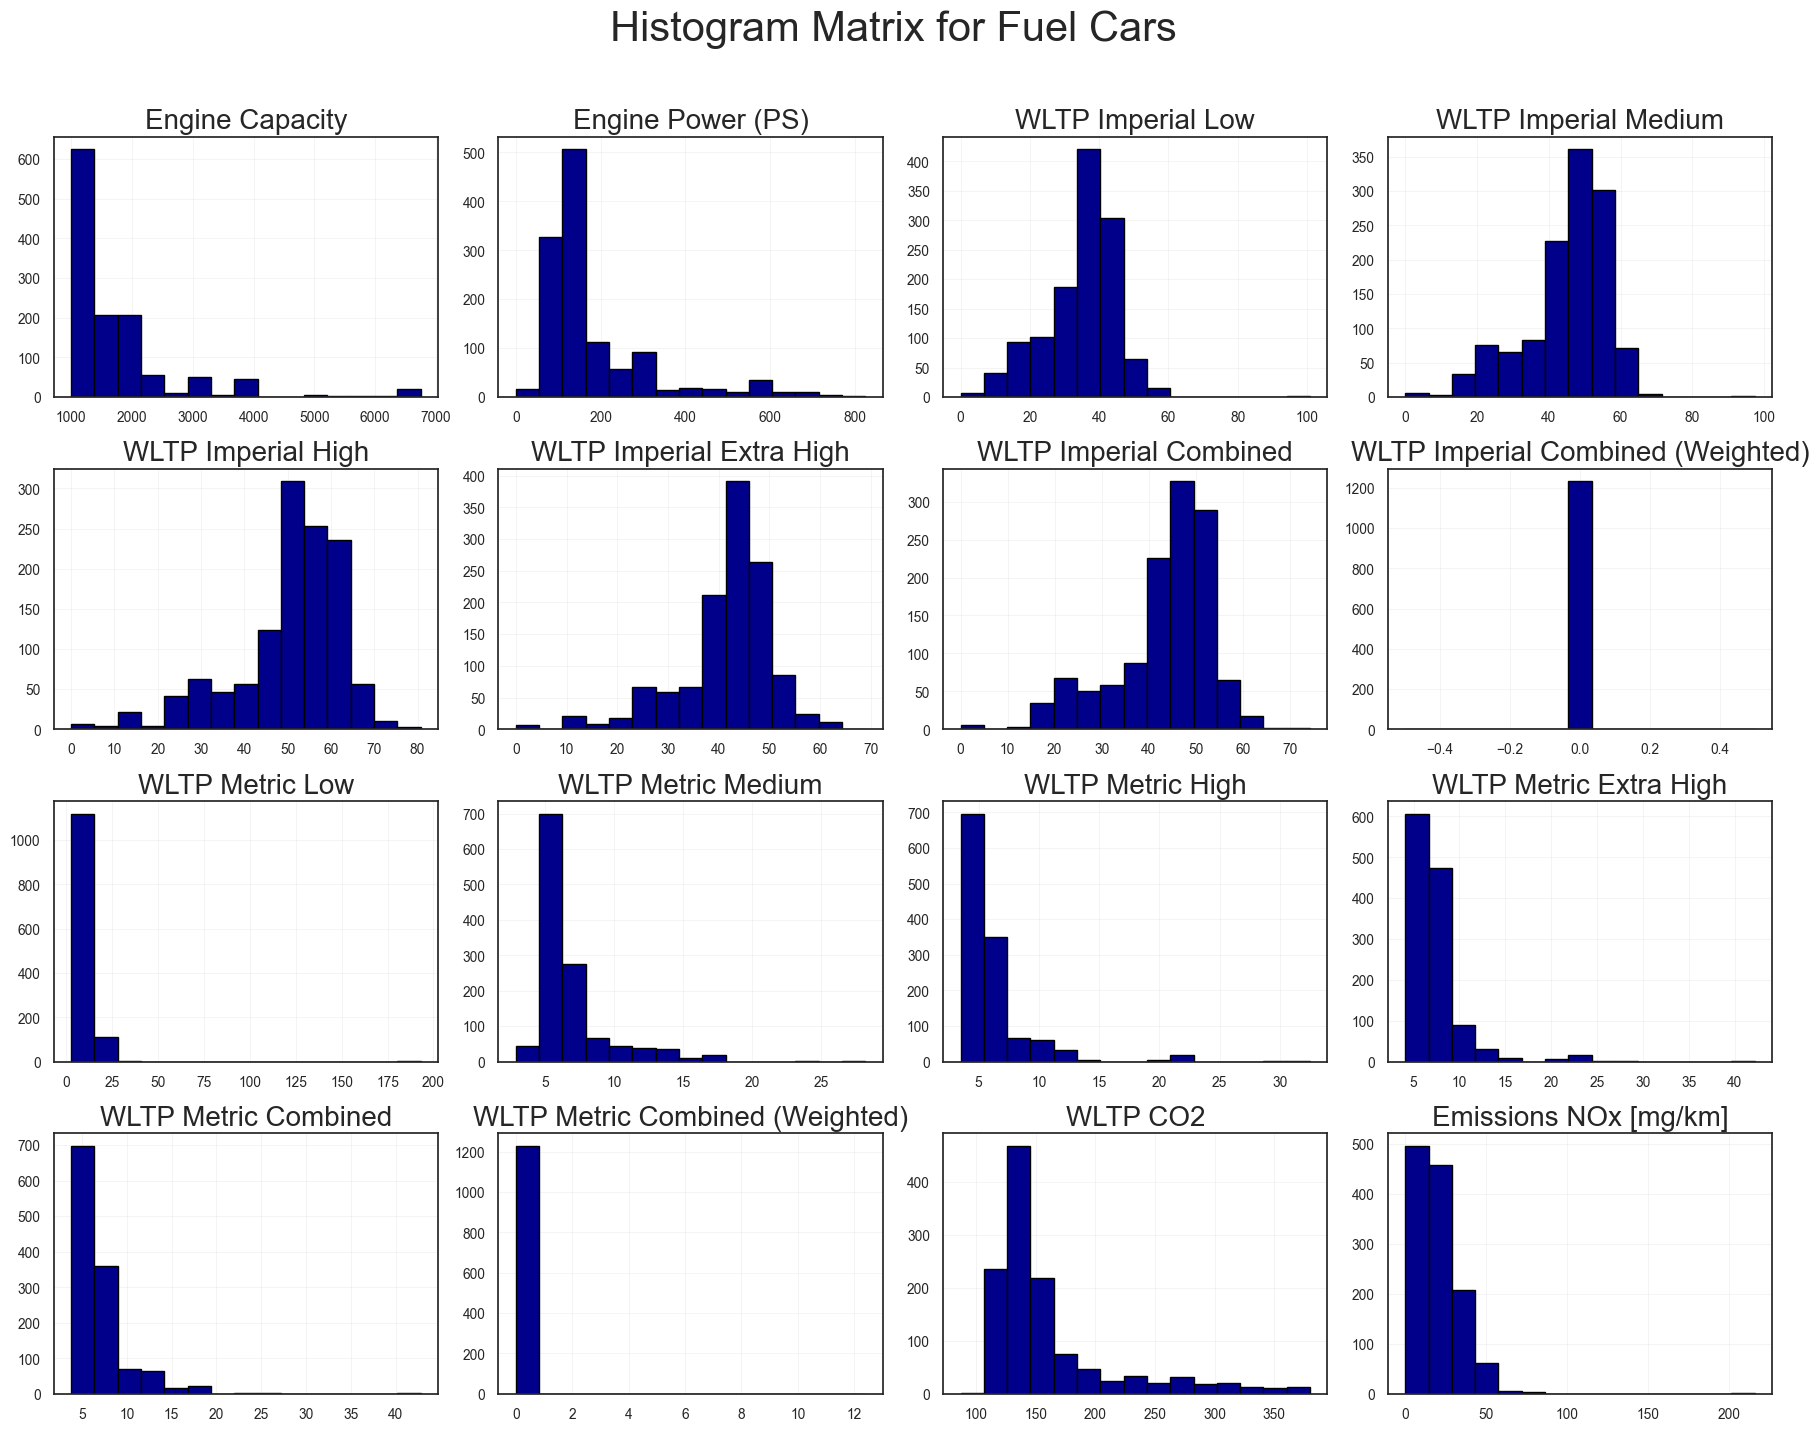

In [1411]:
# -- Histogram Matrix for Fuel Cars --

# Set overall figure size (width, height)
axes = data_fuel.hist(
    figsize=(18, 14),  # larger matrix
    bins=15, # adjust bin count
    color='darkblue',
    edgecolor='black',
    grid=False
)

# Loop over all subplots to format text and labels
for ax in axes.flatten():
    # Bigger titles and smaller axis labels
    ax.set_title(ax.get_title(), fontsize=20)
    ax.set_xlabel(ax.get_xlabel(), fontsize=10)
    ax.set_ylabel(ax.get_ylabel(), fontsize=10)

    ax.grid(alpha=0.3, linewidth=0.5) # thin gridlines for readability

plt.suptitle("Histogram Matrix for Fuel Cars", fontsize=30, y=1.02)
plt.tight_layout()
plt.show()

In [1412]:
# Remove irrelevant columns for regression task
data_fuel = data_fuel.drop(columns=["WLTP Imperial Combined (Weighted)", "WLTP Metric Combined (Weighted)"])
data_fuel.shape

(1233, 17)

Each variable in hybrid vehicles is statistically normalised, we do not see abnormal data distribution here. Hence, no changes to the variables for hybrid vehicles.  

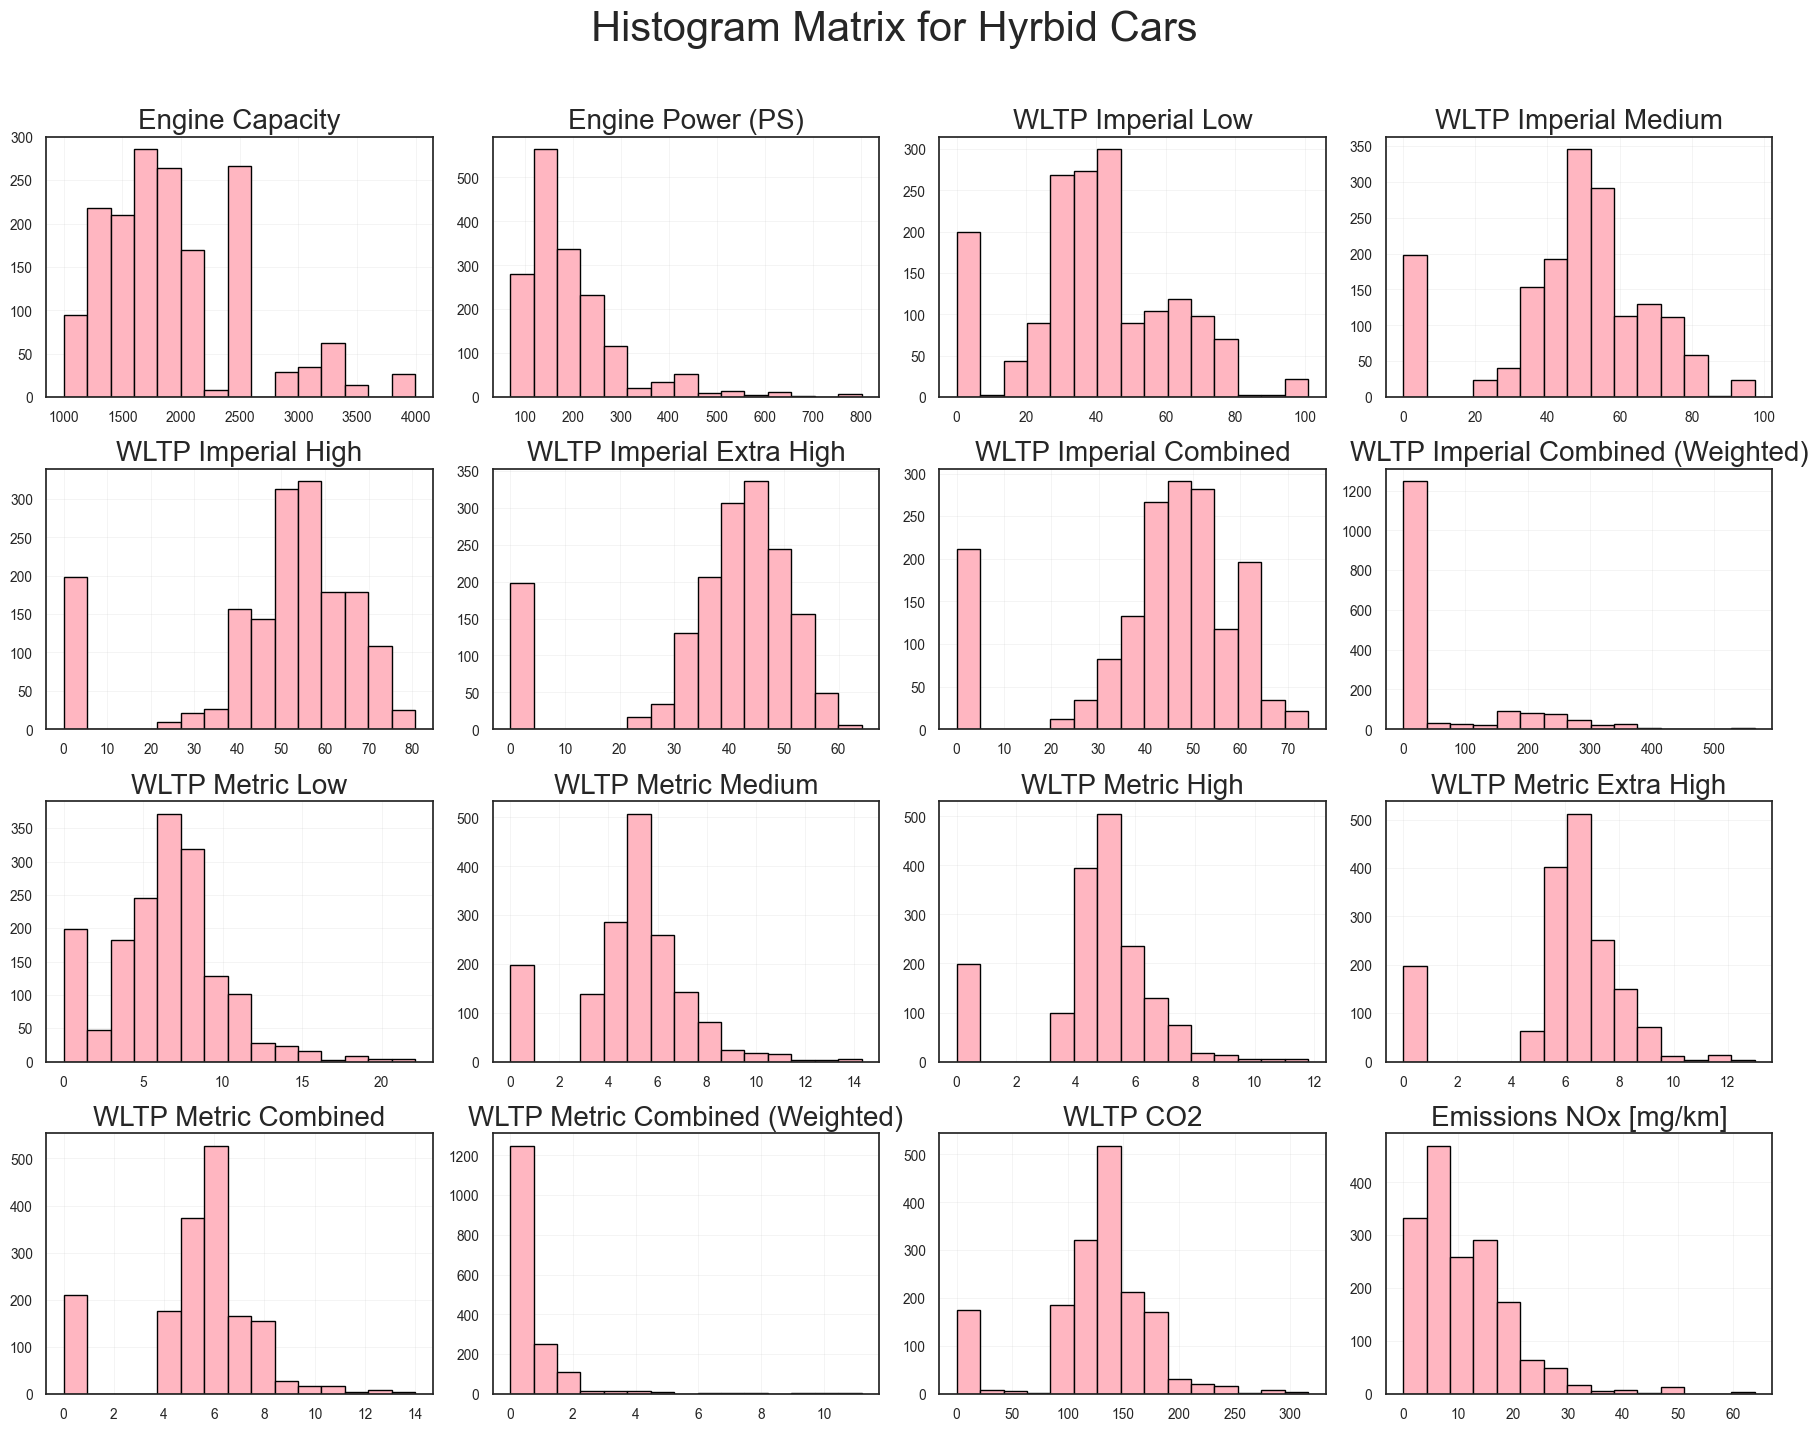

In [1413]:
# -- Histogram Matrix for Hyrbid Cars --

# Set overall figure size (width, height)
axes = data_hybrid.hist(
    figsize=(18, 14),  # larger matrix
    bins=15, # adjust bin count
    color='lightpink',
    edgecolor='black',
    grid=False
)

# Loop over all subplots to format text and labels
for ax in axes.flatten():
    # Bigger titles and smaller axis labels
    ax.set_title(ax.get_title(), fontsize=20)
    ax.set_xlabel(ax.get_xlabel(), fontsize=10)
    ax.set_ylabel(ax.get_ylabel(), fontsize=10)

    ax.grid(alpha=0.3, linewidth=0.5) # thin gridlines for readability

plt.suptitle("Histogram Matrix for Hyrbid Cars", fontsize=30, y=1.02)
plt.tight_layout()
plt.show()

## Outlier Check
To further improve our model and increase the accuracy, we have perform an analysis of the outliers for both datasets. In the fuel vehicles, we can clearly see the outliers are strongly skewed in most of the WLTP Metric variables and highly skewed in Engine Capacity and Power. This could be due to the high-performance models of vehicles. Since, the WLTP Imperial is having the same purpose with a different unit of measurements, we have decided to drop all the WLTP Metric variables which having higher outliers compare to MLTP Imperial. This table showing the updated model for _data_fuel_.


| Category  | Keep | Remove |
|-----------|------| ------ |
| Vehicle   |  Manual or Automatic, Engine Capacity, Fuel Type, Powertrain, Engine Power (PS) | Manufacturer, Model, Description, Transmission, Engine Power (Kw) |
| Fuel Consumption | WLTP Imperial Low, WLTP Imperial Medium, WLTP Imperial High, WLTP Imperial Extra High, WLTP Imperial Combined | Diesel VED Supplement, Testing Scheme, WLTP Imperial Combined (Weighted), WLTP Metric Combined (Weighted), WLTP Metric Low, WLTP Metric Medium, WLTP Metric High, WLTP Metric Extra High, WLTP Metric Combined  |
| Electric Consumption | |Electric energy consumption Miles/kWh, wh/km ,Maximum range (Km), Maximum range (Miles), Equivalent All Electric Range Miles, Equivalent All Electric Range KM, Electric Range City Miles, Electric Range City Km |
| Standard |  | Euro Standard | 
| Emmission | Emissions NOx [mg/km], WLTP CO2  | WLTP CO2 Weighted , THC Emissions [mg/km], THC + NOx Emissions [mg/km], Particulates [No.] [mg/km], RDE NOx Urban, RDE NOx Combined, Noise Level dB(A) |
| Date | | Date of change |

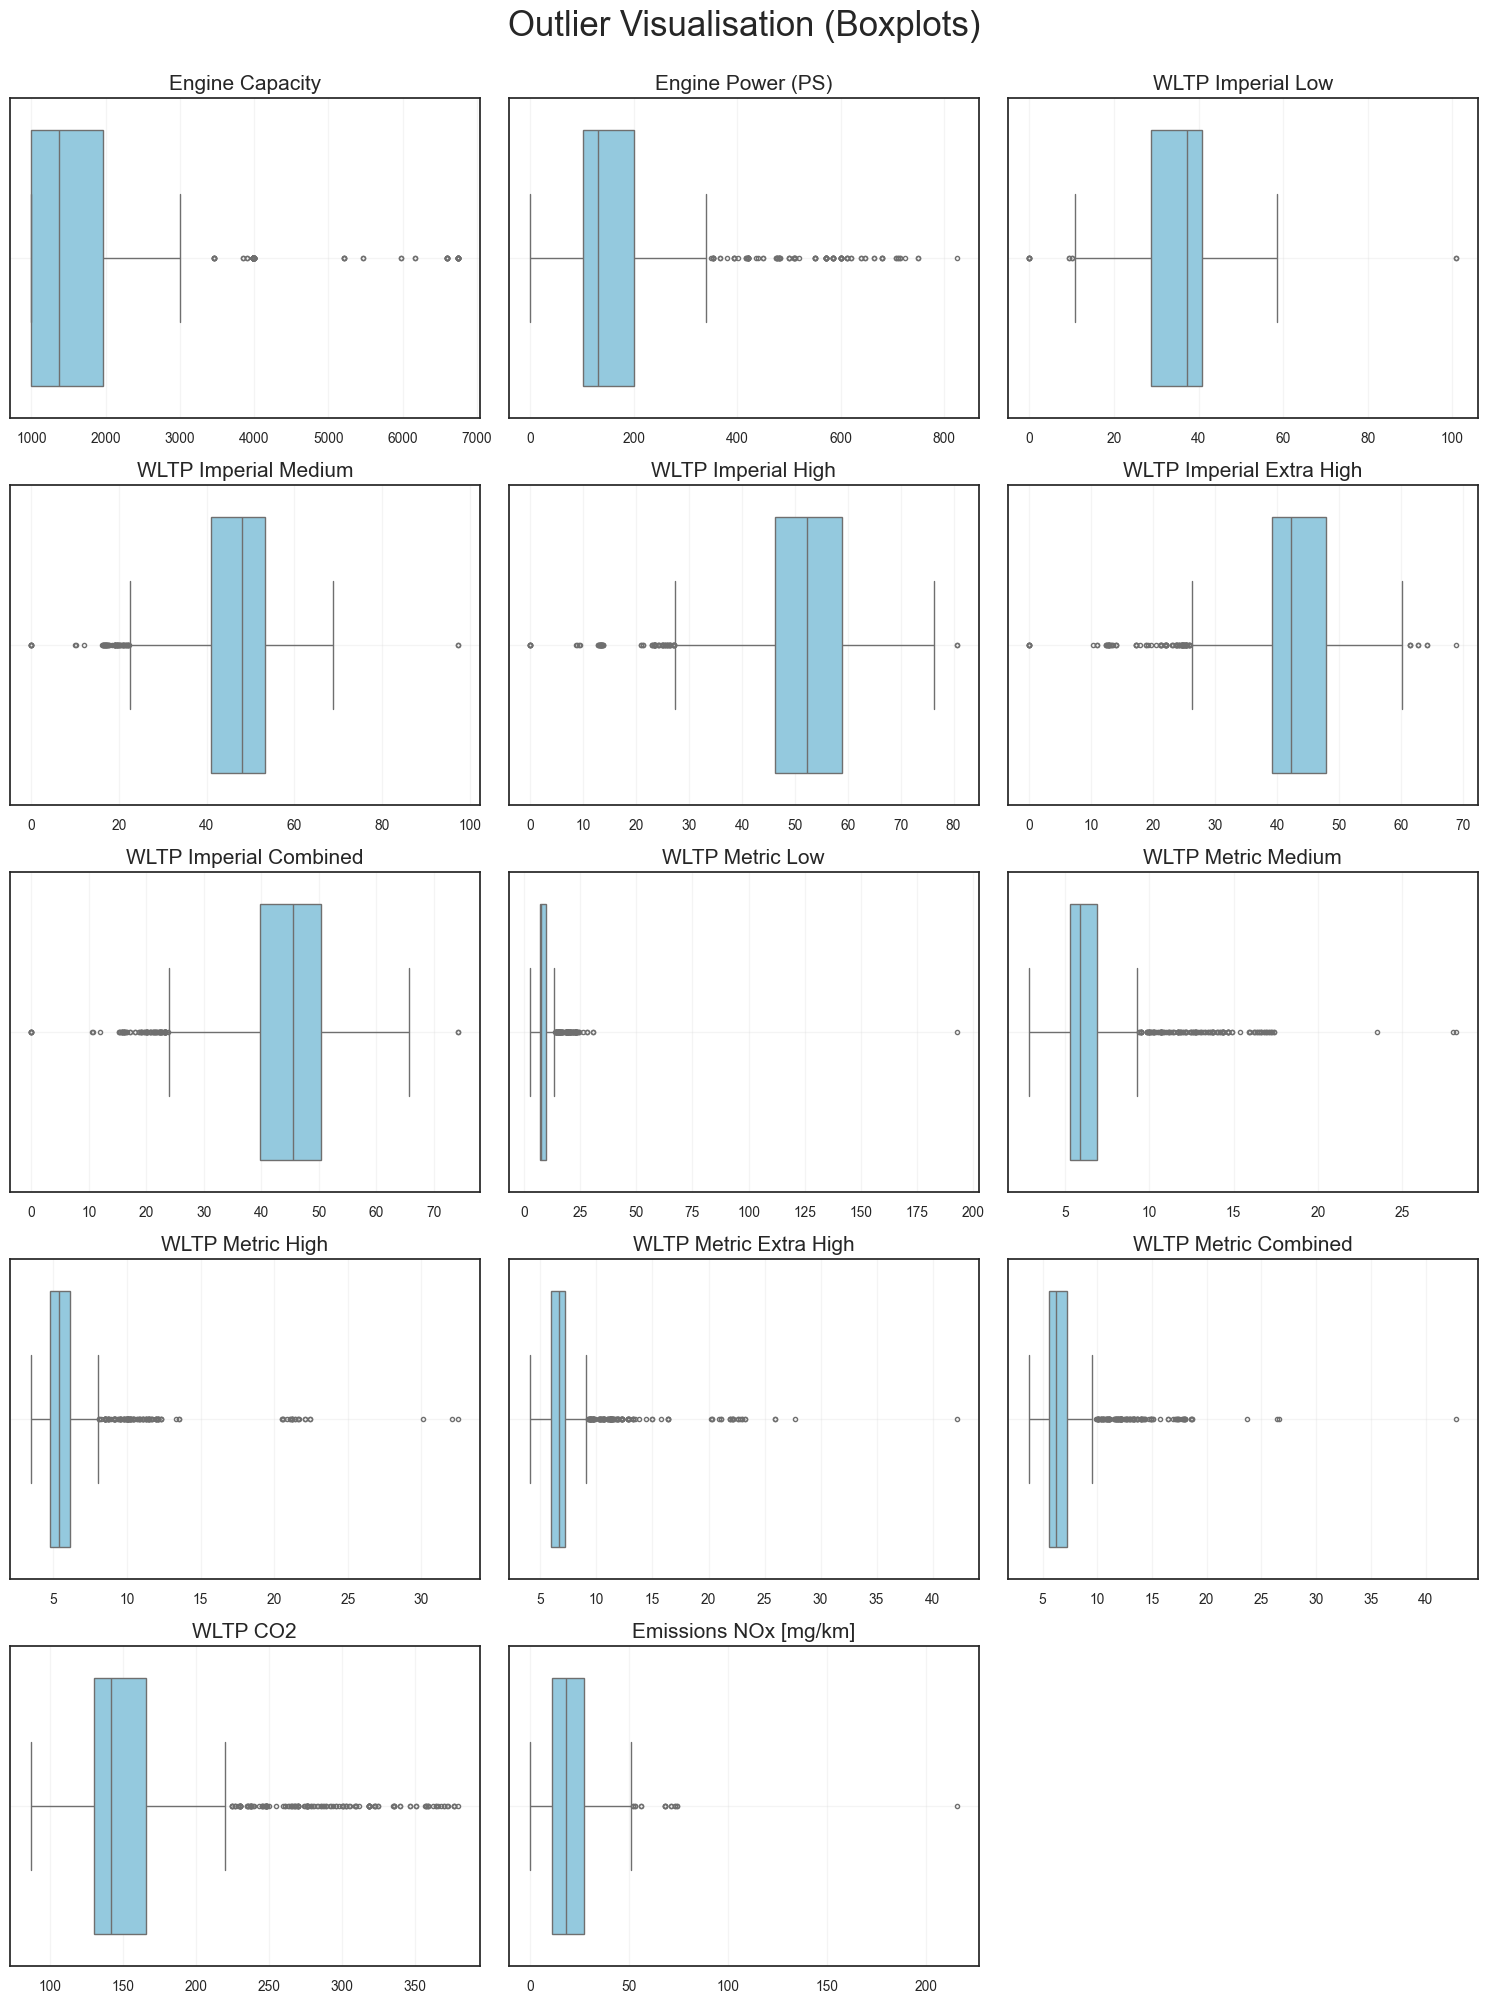

In [1414]:
# A reusable function to visualise outliers, arguments: dataset
def outlier_check(data):
    # Select only numeric columns
    numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    
    if len(numeric_cols) == 0:
        print("No numeric columns found in the dataset.")
        return
    
    # Determine layout
    n_cols = 3
    n_rows = int(np.ceil(len(numeric_cols) / n_cols))
    
    # Set up figure
    plt.figure(figsize=(n_cols * 5, n_rows * 4))
    plt.suptitle("Outlier Visualisation (Boxplots)", fontsize=25, y =1)
    
    # Create boxplots for each numeric column
    for idx, col in enumerate(numeric_cols, 1):
        plt.subplot(n_rows, n_cols, idx)
        sns.boxplot(x=data[col], color='skyblue', fliersize=3, linewidth=1)
        plt.title(col, fontsize=15)
        plt.xlabel("")
        plt.grid(alpha=0.2)
    
    plt.tight_layout()
    plt.show()

outlier_check(data_fuel)

In [1415]:
removed_variables_fuel = [ "WLTP Metric Low", "WLTP Metric Medium",
                            "WLTP Metric High", "WLTP Metric Extra High",
                            "WLTP Metric Combined" ]

print(f"Data shape before removing columns: {data_fuel.shape}")

data_fuel = data_fuel.drop(columns=removed_variables_fuel)
print(f"Data shape after removing columns: {data_fuel.shape}")

Data shape before removing columns: (1233, 17)
Data shape after removing columns: (1233, 12)


Same for fuel vehicles, it seems to be a high outliers in WLTP Metric for hybrid vehicles. Therefore, these variables will be removed from hybrid vehicles dataset too. Here is the table showing the updated columns remain in _data_hybrid_. 

| Category  | Keep | Remove |
|-----------|------| ------ |
| Vehicle   |  Manual or Automatic, Engine Capacity, Fuel Type, Powertrain, Engine Power (PS) | Manufacturer, Model, Description, Transmission, Engine Power (Kw) |
| Fuel Consumption | WLTP Imperial Low, WLTP Imperial Medium, WLTP Imperial High, WLTP Imperial Extra High, WLTP Imperial Combined | Diesel VED Supplement, Testing Scheme, WLTP Metric Low, WLTP Metric Medium, WLTP Metric High, WLTP Metric Extra High, WLTP Metric Combined, WLTP Metric Combined (Weighted), WLTP Imperial Combined (Weighted) |
| Electric Consumption | |Electric energy consumption Miles/kWh, wh/km ,Maximum range (Km), Maximum range (Miles), Equivalent All Electric Range Miles, Equivalent All Electric Range KM, Electric Range City Miles, Electric Range City Km |
| Standard |  | Euro Standard | 
| Emmission | Emissions NOx [mg/km], WLTP CO2  | WLTP CO2 Weighted , THC Emissions [mg/km], THC + NOx Emissions [mg/km], Particulates [No.] [mg/km], RDE NOx Urban, RDE NOx Combined, Noise Level dB(A) |
| Date | | Date of change |

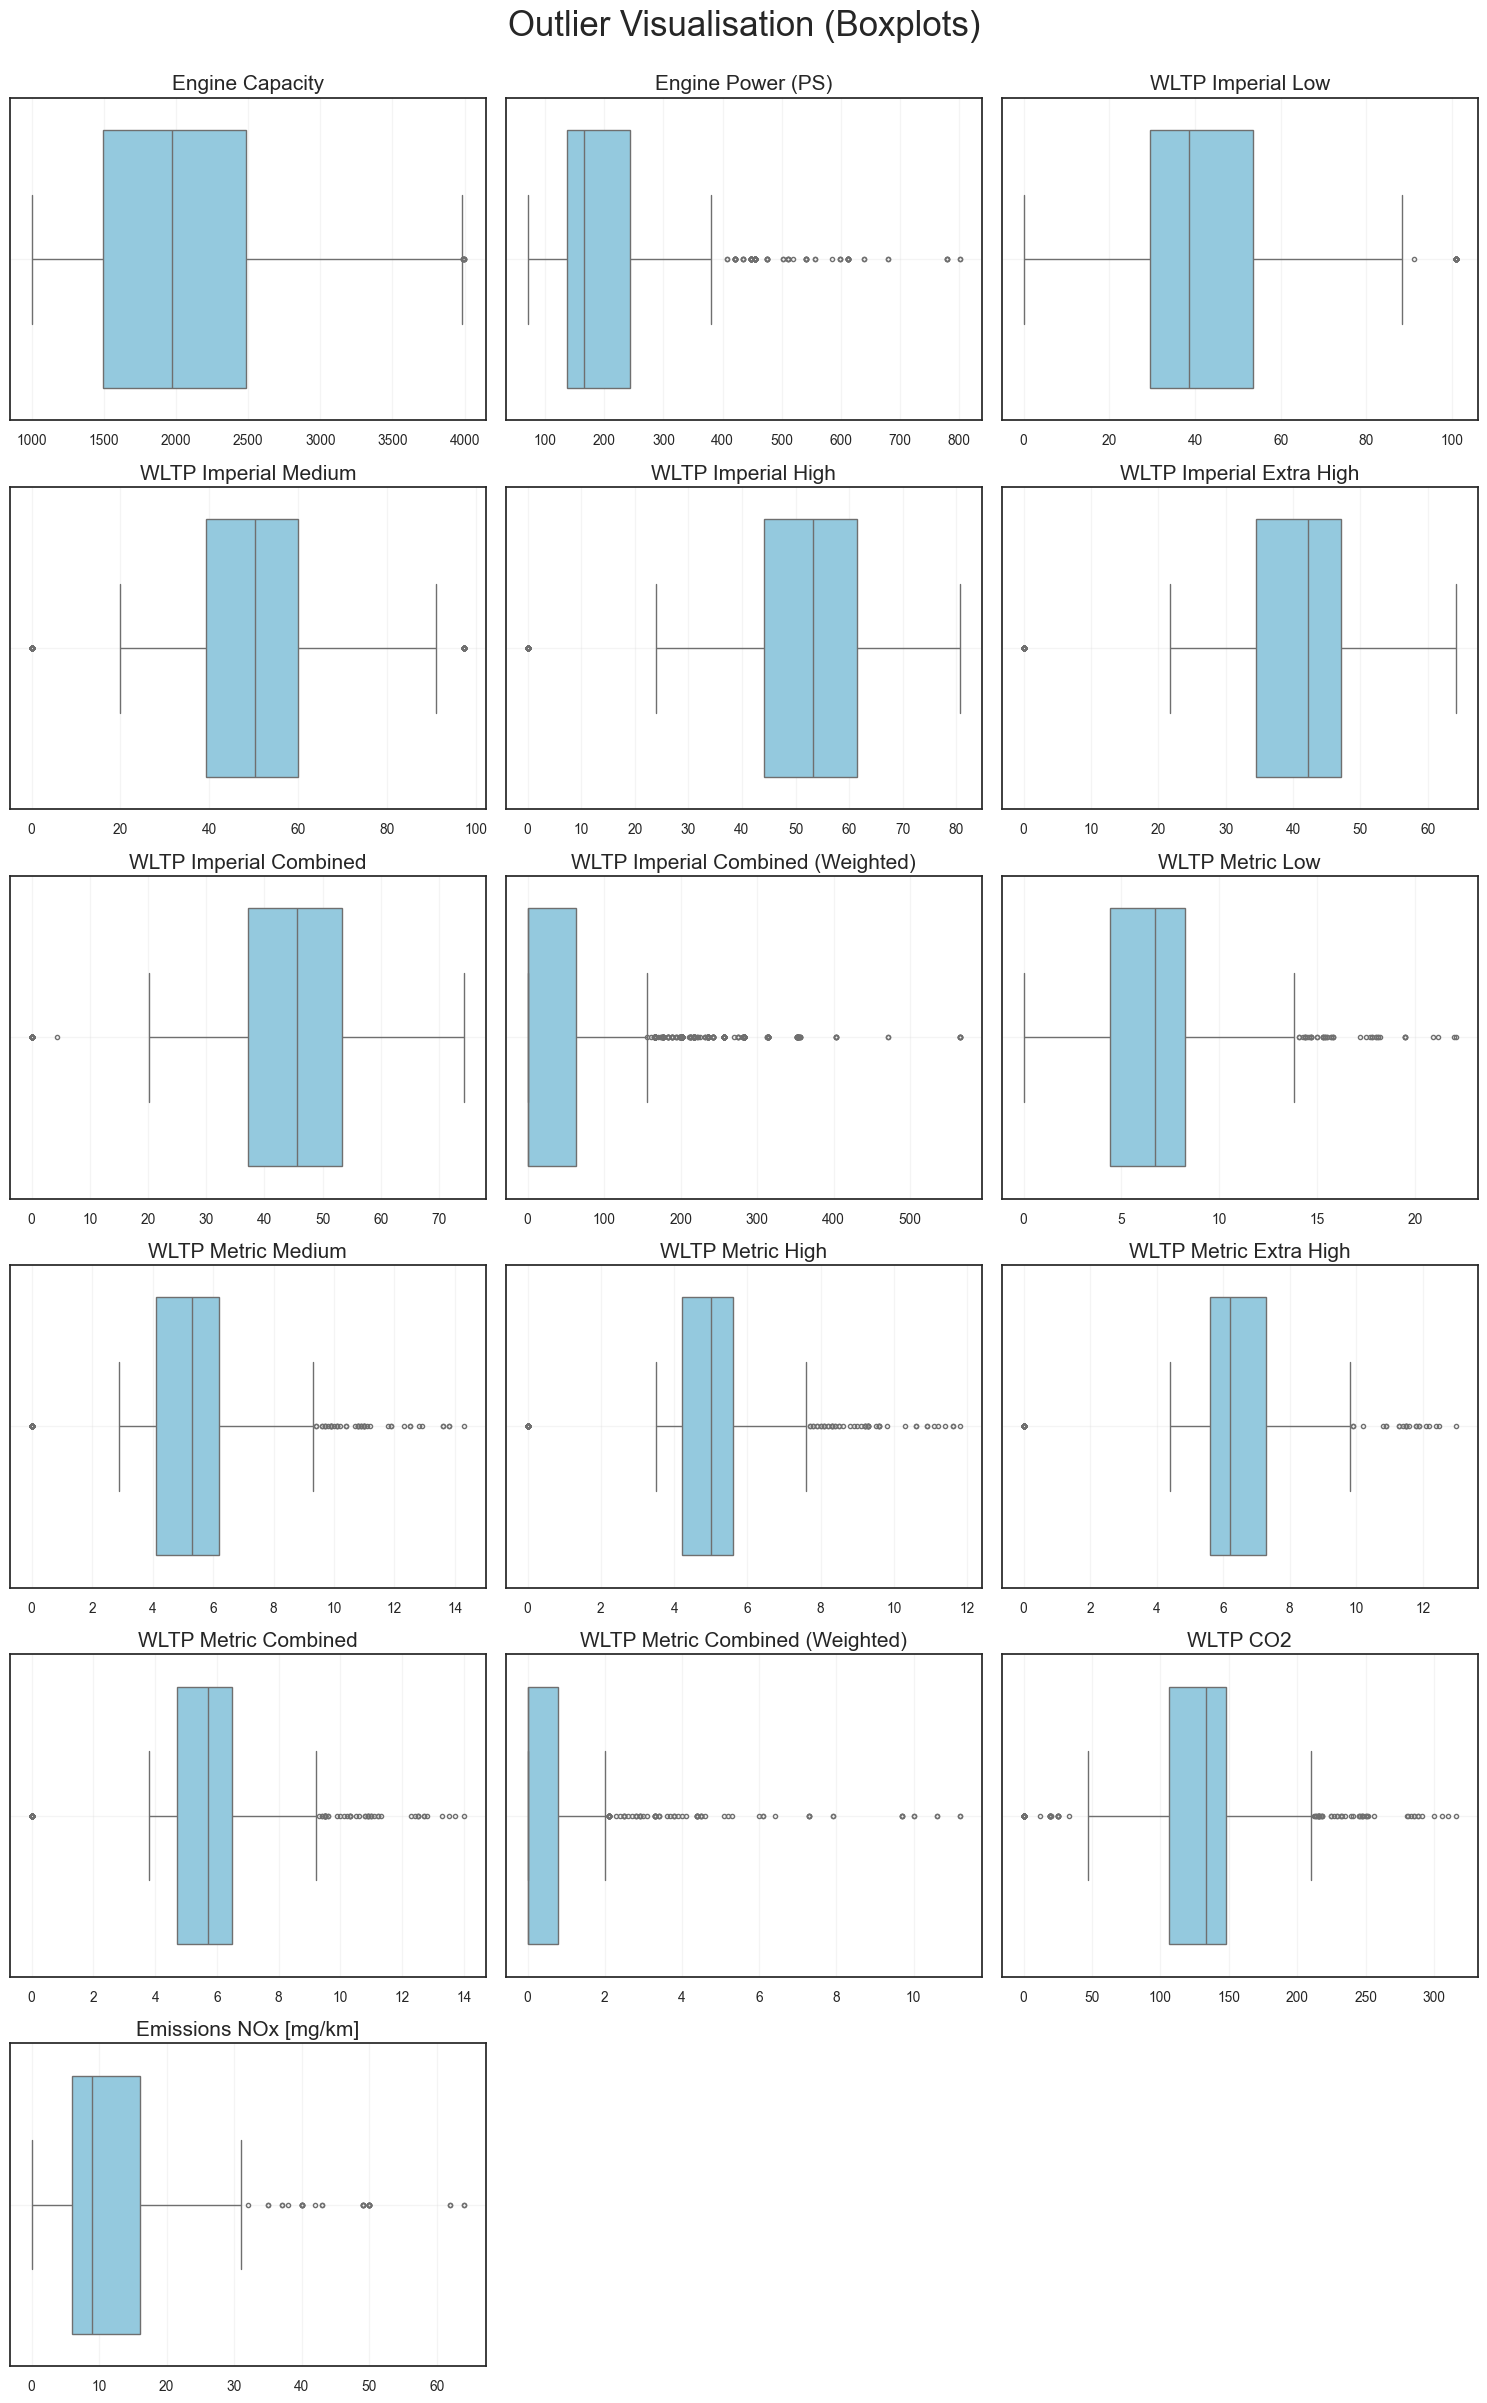

In [1416]:
outlier_check(data_hybrid)

In [1417]:
removed_variables_hybrid = [ "WLTP Metric Low", "WLTP Metric Medium",
                            "WLTP Metric High", "WLTP Metric Extra High",
                            "WLTP Metric Combined", "WLTP Metric Combined (Weighted)",
                            "WLTP Imperial Combined (Weighted)" ]

print(f"Data shape before removing columns: {data_hybrid.shape}")

data_hybrid = data_hybrid.drop(columns=removed_variables_hybrid)
print(f"Data shape after removing columns: {data_hybrid.shape}")

Data shape before removing columns: (1683, 19)
Data shape after removing columns: (1683, 12)


## Cross Validation
Now, we have the final model with all the features and target variables to train and test and model. Before we start the model, a _data_split_ function was created to split the _data_fuel_ and _data_hybrid_ into train, validate, and test datasets. The datasets were split into **80% for training, 10% for validations and 10% for testing**.

After splitting the data, we have created a function called _train_lasso_with_cv_ to use **Lasso** model for feature selection with a **10-fold** cross validations. Based on the results from Lasso model, we have designed to refine the Lasso model again with the best L1 regularisation strength (_alphas_). With the results from Lasso model, we can understand the errors using **mean squared error (MSE)** and variances by calculating the **r2_score** as well as listing the coefficient of each features. 

In [1418]:
# Data Splitting Function into training set, test set, and validation set
np.random.seed(42) # for reproducibility

def data_split(target: str, data: pd.DataFrame, random_state: int = 42):
    assert target in data.columns, f"Target '{target}' not in dataframe."
    
    # Split X/y
    X = data.drop(columns=[target])
    y = data[target]
    
    # Simple numeric imputation (if there are any remaining NaNs)
    # X = X.fillna(X.mean(numeric_only=True)).fillna(0)
    
    # 80 / 20 split, then 10 / 10 from the 20
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, 
                                                         random_state=random_state)
    X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.50, 
                                                     random_state=random_state)
     
    # Encode categorical variables as dummy/one-hot columns
    X_train = pd.get_dummies(X_train, drop_first=True, dtype=float)
    X_val   = pd.get_dummies(X_val,   drop_first=True, dtype=float)
    X_test  = pd.get_dummies(X_test,  drop_first=True, dtype=float)

    #Re-index columns after encoding
    train_cols = X_train.columns
    X_val  = X_val.reindex(columns=train_cols, fill_value=0)
    X_test = X_test.reindex(columns=train_cols, fill_value=0)
    
    #Scaling the X data
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    return {
         "X_train": X_train,
         "X_val": X_val,
         "X_test": X_test,
         "y_train": y_train,
         "y_val": y_val,
         "y_test": y_test
    }     

#reuse this part to access the splitted data.
splits = data_split("WLTP CO2", data_fuel)

# Access the data 
X_train = splits["X_train"]
X_val   = splits["X_val"]
X_test  = splits["X_test"]
y_train = splits["y_train"]
y_val   = splits["y_val"]
y_test  = splits["y_test"]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)
print(X_train[0:5,:])

(986, 13)
(124, 13)
(123, 13)
[[-0.69355105 -0.66468299  0.23878138  0.22261852  0.16192353  0.0135079
   0.15199583 -1.26703709 -0.96022252  0.5139091  -0.19466571  0.12428995
  -0.11558867]
 [ 3.44051473  3.98740879 -2.37420157 -2.1867223  -2.14748521 -2.05174708
  -2.26179734  0.2015991   1.04142527  0.5139091  -0.19466571  0.12428995
  -0.11558867]
 [-0.69355105 -0.50040367  0.59553551  0.43249142  0.31956235  0.087267
   0.29071957 -1.26703709  1.04142527  0.5139091  -0.19466571  0.12428995
  -0.11558867]
 [-0.20296869 -0.23158296 -0.03119472 -0.14675777 -0.18488188 -0.16562136
  -0.08845866 -1.26703709  1.04142527  0.5139091  -0.19466571  0.12428995
  -0.11558867]
 [-0.69453418 -0.81402783  1.51152584  1.47346097  1.34421469  0.86700613
   1.23404104 -0.62849962 -0.96022252  0.5139091  -0.19466571  0.12428995
  -0.11558867]]


In [1419]:
def train_lasso_with_cv(target: str,
                        data: pd.DataFrame,
                        random_state: int = 42, # follow same seed for reproducibility
                        alphas=None,
                        cv: int = 5,
                        refine: bool = True,
                        refine_span: float = 1.5,
                        refine_points: int = 15):
    splits = data_split(target=target, data=data, random_state=random_state) #reuse data_split function

    X_train = splits["X_train"]
    X_val   = splits["X_val"]
    X_test  = splits["X_test"]
    y_train = splits["y_train"]
    y_val   = splits["y_val"]
    y_test  = splits["y_test"]

    # Coefficient check
    X_train_raw = data.loc[y_train.index].drop(columns=[target])
    feature_names = pd.get_dummies(X_train_raw, drop_first=True, dtype=float).columns
    if len(feature_names) != X_train.shape[1]:
        feature_names = pd.Index([f"feature_{i}" for i in range(X_train.shape[1])])

    lasso_cv = LassoCV(alphas=alphas, cv=cv, random_state=random_state)
    lasso_cv.fit(X_train, y_train)

    y_train_pred = lasso_cv.predict(X_train)
    y_val_pred   = lasso_cv.predict(X_val)
    y_test_pred  = lasso_cv.predict(X_test)

    def rmse(y_true, y_pred):
        return mean_squared_error(y_true, y_pred)

    coef_series = pd.Series(lasso_cv.coef_, index=feature_names)
    nonzero_coefs = coef_series[coef_series != 0].sort_values(key=np.abs, ascending=False)

    results = {
        "model": lasso_cv,
        "best_alpha": lasso_cv.alpha_,
        "train_rmse": rmse(y_train, y_train_pred),
        "val_rmse": rmse(y_val, y_val_pred),
        "val_r2": r2_score(y_val, y_val_pred),
        "test_rmse": rmse(y_test, y_test_pred),
        "test_r2": r2_score(y_test, y_test_pred),
        "coefficients": nonzero_coefs,
    }
    # Refine the model by regularise with best alpha
    if refine and lasso_cv.alpha_ > 0:
        lower = max(lasso_cv.alpha_ / refine_span, 1e-6)
        upper = lasso_cv.alpha_ * refine_span
        alpha_grid = np.linspace(lower, upper, refine_points)
        alpha_grid = np.unique(alpha_grid)
        refined_cv = LassoCV(alphas=alpha_grid, cv=cv, random_state=random_state)
        refined_cv.fit(X_train, y_train)

        ref_val_pred  = refined_cv.predict(X_val)
        ref_test_pred = refined_cv.predict(X_test)

        results["refined_search"] = {
            "alphas": alpha_grid,
            "best_alpha": refined_cv.alpha_,
            "val_rmse": rmse(y_val, ref_val_pred),
            "val_r2": r2_score(y_val, ref_val_pred),
            "test_rmse": rmse(y_test, ref_test_pred),
            "test_r2": r2_score(y_test, ref_test_pred),
            "coefficients": pd.Series(refined_cv.coef_, index=feature_names)[
                refined_cv.coef_ != 0
            ].sort_values(key=np.abs, ascending=False),
        }

    return results

We have done the training for both datasets _data_fuel_ and _data_hybrid with the two target variables _WLTP CO2_ and _Emissions NOx [mg/km]_ that we have defined above. Below table is the results from the _lasso_ model training with _10-fold_ cross validation.

| Metric              | Fuel / CO2 (12 features) | Fuel / CO2 (3 features) | Fuel / NOx (12 features) | Fuel / NOx (3 features) | Hybrid / CO2 (12 features) | Hybrid / CO2 (3 features) | Hybrid / NOx (12 features) | Hybrid / NOx (3 features) |
|---------------------|------------------------|-----------------------|------------------------|-----------------------|--------------------------|-------------------------|--------------------------|-------------------------|
| Best alpha          | 0.054                  | 0.022                 | 0.022                  | 0.002                 | 0.103                    | 0.022                   | 0.004                    | 0.055                   |
| Train RMSE          | 197.082                | 2071.979              | 213.583                | 238.598               | 1359.811                 | 2071.979                | 45.390                   | 74.931                  |
| Validate RMSE       | 270.483                | 1912.145              | 1272.888               | 171.254               | 1044.115                 | 1912.145                | 71.701                   | 98.815                  |
| Validate R²         | 0.926                  | 0.055                 | -6.459                 | -0.003                | 0.484                    | 0.055                   | 0.279                    | 0.007                   |
| Test RMSE           | 247.201                | 2080.948              | 1172.173               | 149.236               | 1525.036                 | 2080.948                | 24.205                   | 45.544                  |
| Test R²             | 0.890                  | 0.251                 | 6.831                  | 0.002                 | 0.451                    | 0.251                   | 0.463                    | -0.009                  |

Based on the _alphas_ returned from first round of training, we have run the _lasso_ model again with following results.

| Metric (refined)    | Fuel / CO2 (12 features) | Fuel / CO2 (3 features) | Fuel / NOx (12 features) | Fuel / NOx (3 features) | Hybrid / CO2 (12 features) | Hybrid / CO2 (3 features) | Hybrid / NOx (12 features) | Hybrid / NOx (3 features) |
|---------------------|------------------------|-----------------------|------------------------|-----------------------|--------------------------|-------------------------|--------------------------|-------------------------|
| Validate RMSE       | 261.047                | 1912.280              | 1276.104               | 171.228               | 1043.926                 | 1912.280                | 71.691                   | 98.813                  |
| Validate R²         | 0.928                  | 0.055                 | -6.478                 | -0.003                | 0.484                    | 0.055                   | 0.279                    | 0.007                   |
| Test RMSE           | 236.887                | 2081.085              | 1175.241               | 149.221               | 1525.295                 | 2081.085                | 24.225                   | 45.544                  |
| Test R²             | 0.894                  | 0.251                 | -6.852                 | 0.003                 | 0.451                    | 0.251                   | 0.462                    | -0.009                  |

From the _lasso_ training, we found that the model with all the 12 features are working fine in both datasets for fuel and hybrid vehicle when we examine the correlation with CO2 and NOx. The errors have increased drastically after reduced to 3 features only. Eventhough the model for Fuel/NOx was strongly negative in validation R2, we are keeping the 12 features to standardised the features selection. We will consider an algorithm improvements in the future. 

In [1420]:
# Lasso for fuel/CO2
lasso_results = train_lasso_with_cv(target="WLTP CO2", data=data_fuel, cv=10)
lasso_results


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1641: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(


{'model': LassoCV(alphas=None, cv=10, random_state=42),
 'best_alpha': np.float64(0.053836134461235155),
 'train_rmse': 197.08208119442276,
 'val_rmse': 270.48320504295214,
 'val_r2': 0.925691856024911,
 'test_rmse': 247.2013857718128,
 'test_r2': 0.8897943003613373,
 'coefficients': Engine Capacity                                29.980868
 WLTP Imperial Extra High                      -18.163245
 WLTP Imperial Low                              -7.004502
 Powertrain_Micro Hybrid                        -3.287962
 WLTP Imperial Medium                           -2.514488
 Engine Power (PS)                               2.252587
 Emissions NOx [mg/km]                           1.981455
 Fuel Type_Petrol                               -1.859377
 Powertrain_Internal Combustion Engine (ICE)    -1.266613
 WLTP Imperial High                              0.880499
 Fuel Type_Petrol / LPG                         -0.420860
 Manual or Automatic_Manual                      0.160358
 dtype: float64,
 'r

In [1421]:
# Lasso Fuel/CO2 - reduced features
target_col = "WLTP CO2"

# Create a copy of the data
features = data_fuel.copy()

# Keep only a subset of columns
keep_cols = ['Engine Capacity', 'Engine Power (PS)','WLTP Imperial Combined', target_col]
features = features[keep_cols]

# Train Lasso on the customised feature set
lasso_results = train_lasso_with_cv(target=target_col, data=features, cv=10)
lasso_results

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1641: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(


{'model': LassoCV(alphas=None, cv=10, random_state=42),
 'best_alpha': np.float64(0.14299349902356182),
 'train_rmse': 218.63665323403046,
 'val_rmse': 218.49243926023294,
 'val_r2': 0.9399749510087342,
 'test_rmse': 176.8594168856871,
 'test_r2': 0.9211536953374333,
 'coefficients': Engine Capacity           30.594180
 WLTP Imperial Combined   -25.839366
 Engine Power (PS)          0.515220
 dtype: float64,
 'refined_search': {'alphas': array([0.095329  , 0.10384052, 0.11235203, 0.12086355, 0.12937507,
         0.13788659, 0.14639811, 0.15490962, 0.16342114, 0.17193266,
         0.18044418, 0.1889557 , 0.19746721, 0.20597873, 0.21449025]),
  'best_alpha': np.float64(0.12086355274610582),
  'val_rmse': 218.45993191857707,
  'val_r2': 0.9399838815455623,
  'test_rmse': 176.9645967402669,
  'test_r2': 0.9211068047448677,
  'coefficients': Engine Capacity           30.603236
  WLTP Imperial Combined   -25.850768
  Engine Power (PS)          0.520484
  dtype: float64}}

In [1422]:
# Lasso for fuel/NOx
lasso_results = train_lasso_with_cv(target="Emissions NOx [mg/km]", data=data_fuel, cv=10)
lasso_results


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1641: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.299e+01, tolerance: 2.171e+01
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regulari

{'model': LassoCV(alphas=None, cv=10, random_state=42),
 'best_alpha': np.float64(0.022706556704731314),
 'train_rmse': 213.58328945257574,
 'val_rmse': 1272.8883248298037,
 'val_r2': -6.459989275211023,
 'test_rmse': 1172.1732273006585,
 'test_r2': -6.831626065116016,
 'coefficients': WLTP Imperial Low                              10.239227
 WLTP Imperial Medium                           -9.698089
 WLTP CO2                                        7.386423
 Engine Capacity                                -5.546259
 WLTP Imperial High                              5.474811
 Powertrain_Micro Hybrid                         5.072075
 Powertrain_Internal Combustion Engine (ICE)     4.165852
 Fuel Type_Petrol                               -2.613155
 Manual or Automatic_Manual                     -2.128423
 Engine Power (PS)                               1.125785
 Fuel Type_Petrol / LPG                         -0.316801
 WLTP Imperial Extra High                       -0.098101
 dtype: float64,
 

In [1423]:
# Lasso Fuel/NOx - reduced features
target_col = "Emissions NOx [mg/km]"

# Create a copy of the data
features = data_fuel.copy()

# Keep only a subset of columns
keep_cols = ['Engine Capacity', 'Engine Power (PS)','WLTP Imperial Low', target_col]
features = features[keep_cols]

# Train Lasso on the customised feature set
lasso_results = train_lasso_with_cv(target=target_col, data=features, cv=10)
lasso_results

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1641: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(


{'model': LassoCV(alphas=None, cv=10, random_state=42),
 'best_alpha': np.float64(0.0020124354624595528),
 'train_rmse': 238.59879427008886,
 'val_rmse': 171.25402091321084,
 'val_r2': -0.003664763379880087,
 'test_rmse': 149.2362832125419,
 'test_r2': 0.0029095203275829595,
 'coefficients': Engine Capacity      3.110830
 WLTP Imperial Low    2.571660
 Engine Power (PS)   -1.823929
 dtype: float64,
 'refined_search': {'alphas': array([0.00134162, 0.00146141, 0.0015812 , 0.00170099, 0.00182077,
         0.00194056, 0.00206035, 0.00218014, 0.00229993, 0.00241971,
         0.0025395 , 0.00265929, 0.00277908, 0.00289887, 0.00301865]),
  'best_alpha': np.float64(0.003018653193689329),
  'val_rmse': 171.22892024082032,
  'val_r2': -0.0035176564081362827,
  'test_rmse': 149.22074868921243,
  'test_r2': 0.00301331094059365,
  'coefficients': Engine Capacity      3.101575
  WLTP Imperial Low    2.571899
  Engine Power (PS)   -1.814510
  dtype: float64}}

In [1424]:
# Lasso for hybrid/CO2
lasso_results = train_lasso_with_cv(target="WLTP CO2", data=data_hybrid, cv=10)
lasso_results

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1641: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(


{'model': LassoCV(alphas=None, cv=10, random_state=42),
 'best_alpha': np.float64(0.10268122550408759),
 'train_rmse': 1359.8107970223589,
 'val_rmse': 1044.1146153451873,
 'val_r2': 0.48415022846681965,
 'test_rmse': 1525.0355876464441,
 'test_r2': 0.4510001781752073,
 'coefficients': WLTP Imperial Combined                               42.026967
 WLTP Imperial Low                                   -41.162294
 WLTP Imperial Extra High                             32.974556
 Fuel Type_Electricity / Petrol                       21.787401
 Fuel Type_Petrol Electric                            21.042898
 Engine Power (PS)                                    12.952927
 Engine Capacity                                      12.540855
 Powertrain_Range Extended Electric Vehicle (REEV)    10.872598
 Manual or Automatic_Manual                           -7.050259
 Powertrain_Mild Hybrid Electric Vehicle (MHEV)        6.437911
 Emissions NOx [mg/km]                                 3.853434
 dtype: fl

In [1425]:
# Lasso hybrid/CO2 - reduced features
target_col = "WLTP CO2"

# Create a copy of the data
features = data_hybrid.copy()

# Keep only a subset of columns
keep_cols = ['Engine Capacity', 'Engine Power (PS)','WLTP Imperial Combined', target_col]
features = features[keep_cols]

# Train Lasso on the customised feature set
lasso_results = train_lasso_with_cv(target=target_col, data=features, cv=10)
lasso_results

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1641: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(


{'model': LassoCV(alphas=None, cv=10, random_state=42),
 'best_alpha': np.float64(0.021701678167139464),
 'train_rmse': 2071.9793874056763,
 'val_rmse': 1912.14542062172,
 'val_r2': 0.0552954973819314,
 'test_rmse': 2080.9482519861144,
 'test_r2': 0.2508763540855494,
 'coefficients': WLTP Imperial Combined    34.523762
 Engine Power (PS)         12.872387
 Engine Capacity           12.678884
 dtype: float64,
 'refined_search': {'alphas': array([0.01446779, 0.01575955, 0.01705132, 0.01834309, 0.01963485,
         0.02092662, 0.02221838, 0.02351015, 0.02480192, 0.02609368,
         0.02738545, 0.02867722, 0.02996898, 0.03126075, 0.03255252]),
  'best_alpha': np.float64(0.017051318559895293),
  'val_rmse': 1912.2798354942565,
  'val_r2': 0.05522908907745061,
  'test_rmse': 2081.084815587204,
  'test_r2': 0.25082719235235895,
  'coefficients': WLTP Imperial Combined    34.536845
  Engine Power (PS)         12.885183
  Engine Capacity           12.679335
  dtype: float64}}

In [1426]:
# Lasso for hybrid/NOx
lasso_results = train_lasso_with_cv(target="Emissions NOx [mg/km]", data=data_hybrid, cv=10)
lasso_results

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1641: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.789e+02, tolerance: 1.013e+01
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisatio

{'model': LassoCV(alphas=None, cv=10, random_state=42),
 'best_alpha': np.float64(0.004948066919328782),
 'train_rmse': 45.390448405524516,
 'val_rmse': 71.70107501477348,
 'val_r2': 0.27947758287759916,
 'test_rmse': 24.20563248657752,
 'test_r2': 0.4632292749050183,
 'coefficients': Fuel Type_Petrol Electric                           -4.182476
 WLTP Imperial Medium                                -3.992105
 Powertrain_Mild Hybrid Electric Vehicle (MHEV)       3.219553
 Powertrain_Plug-in Hybrid Electric Vehicle (PHEV)   -3.107646
 WLTP Imperial High                                   2.262086
 Engine Capacity                                     -2.139118
 Fuel Type_Electricity / Petrol                      -2.063395
 WLTP Imperial Low                                    1.598328
 WLTP Imperial Combined                              -1.003541
 Engine Power (PS)                                    0.958271
 WLTP CO2                                             0.843595
 Manual or Automatic_M

In [1427]:
# Lasso hybrid/NOx - reduced features
target_col = "Emissions NOx [mg/km]"

# Create a copy of the data
features = data_hybrid.copy()

# Keep only a subset of columns
keep_cols = ['Engine Capacity', 'Engine Power (PS)','WLTP Imperial Medium', target_col]
features = features[keep_cols]

# Train Lasso on the customised feature set
lasso_results = train_lasso_with_cv(target=target_col, data=features, cv=10)
lasso_results

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1641: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(


{'model': LassoCV(alphas=None, cv=10, random_state=42),
 'best_alpha': np.float64(0.055783250410331386),
 'train_rmse': 74.93167545685557,
 'val_rmse': 98.81570382986438,
 'val_r2': 0.007003315382996034,
 'test_rmse': 45.54434206502654,
 'test_r2': -0.00996615262065248,
 'coefficients': Engine Capacity        -0.440297
 WLTP Imperial Medium    0.161393
 dtype: float64,
 'refined_search': {'alphas': array([0.03718883, 0.04050927, 0.0438297 , 0.04715013, 0.05047056,
         0.05379099, 0.05711142, 0.06043185, 0.06375229, 0.06707272,
         0.07039315, 0.07371358, 0.07703401, 0.08035444, 0.08367488]),
  'best_alpha': np.float64(0.05379099146710527),
  'val_rmse': 98.81353096747513,
  'val_r2': 0.007025150426061222,
  'test_rmse': 45.54409355961425,
  'test_r2': -0.009960641902003742,
  'coefficients': Engine Capacity        -0.441738
  WLTP Imperial Medium    0.162834
  dtype: float64}}

## Neural Network - Regression Tasks

**Variables Selection**
The following variables should be used to develop neural networks model.


In [1428]:
#print current variables from the fuel cars dataset
print(data_fuel.columns)
print(data_fuel.shape)


Index(['Manual or Automatic', 'Engine Capacity', 'Fuel Type', 'Powertrain',
       'Engine Power (PS)', 'WLTP Imperial Low', 'WLTP Imperial Medium',
       'WLTP Imperial High', 'WLTP Imperial Extra High',
       'WLTP Imperial Combined', 'WLTP CO2', 'Emissions NOx [mg/km]'],
      dtype='object')
(1233, 12)


In [1429]:
#print current variables from the hybrid cars dataset
print(data_hybrid.columns)
print(data_hybrid.shape)

Index(['Manual or Automatic', 'Engine Capacity', 'Fuel Type', 'Powertrain',
       'Engine Power (PS)', 'WLTP Imperial Low', 'WLTP Imperial Medium',
       'WLTP Imperial High', 'WLTP Imperial Extra High',
       'WLTP Imperial Combined', 'WLTP CO2', 'Emissions NOx [mg/km]'],
      dtype='object')
(1683, 12)


As this is regression tasks, hidden layers will be applied with ReLU - max(0,x) as activation method to keep gradients strong and captures nonlinearity. The output layer will apply linear approach without activation to allow continuous outputs from the gas emissions, with no upper and lower limit

**Parameters to train all the model:**
* Step size: 0.004. To sufficient enough to learn
* Iteration: 2,001. To 
* Number of nodes in each layer: 10-25 nodes.

### Neural Network Regression (2 Layers)

In [1430]:
# Reusable function for Neural Network regression task - simple 1 hidden layer NN
def neural_network_regression(target: str, data: pd.DataFrame, random_state: int = 42):
    assert target in data.columns, f"Target '{target}' not in dataframe."

    #reuse this part to access the splitted data.
    splits = data_split(target, data)

    # Access the data 
    X_train = splits["X_train"]
    X_val   = splits["X_val"]
    X_test  = splits["X_test"]
    y_train = splits["y_train"]
    y_val   = splits["y_val"]
    y_test  = splits["y_test"]

    # Flatten target arrays
    y_train = y_train.values.reshape(-1, 1)
    y_val   = y_val.values.reshape(-1, 1)
    y_test  = y_test.values.reshape(-1, 1)
    
    # Define NN dimensions
    N = len(y_train) # number of samples
    D_in = X_train.shape[1] # number of features - 12
    D_out = 1 # number of outputs
    H = 20 # number of hidden neurons, based on number of features

    # Initialize weights
    W0 = normal(0, 0.1, size=(D_in, H))
    W1 = normal(0, 0.1, size=(H, D_out))

    # Training loop
    eta = 0.0005

    loss_history = []
    for i in range(2001):
        # forward pass
        
        ## Bias Terms
        b0 = np.zeros((1, H))
        b1 = np.zeros((1, 1))

        # -- Forward Pass --
        # Hidden Layer 1
        z1 = X_train.dot(W0) + b0
        z1 = np.clip(z1, -500, 500)
        a1 = np.maximum(0,z1)
        
        # Output Layer
        z2 = a1.dot(W1) + b1 # Linear output (no activation)
        y_pred = z2 
        
        Loss = np.mean((y_pred - y_train) ** 2)
        loss_history.append(Loss)

        # # print loss every 100 iterations
        # if i % 100 == 0:
        #     print(f"Iteration {i}: Loss {Loss:.4f}")
    
        # -- Backward Pass --
        # Derivative of Loss wrt output
        da2 = 2.0 * (y_pred - y_train)

        # Gradients for output layer
        dW1 = a1.T.dot(da2)
        # db1 = np.sum(da2, axis=0, keepdims=True)

        
        # Backprop into hidden layer (ReLU derivative)
        da1 = da2.dot(W1.T)
        dz1 = da1 * (z1 > 0)  # ReLU derivative → 1 where z1>0, else 0
        
        dW0 = X_train.T.dot(dz1)
        db0 = np.sum(dz1, axis=0, keepdims=True)
            
        # parameter updates (weights and bias)
        W0 -= eta * dW0 # weights update for features
        b0 -= eta * db0
        
        W1 -= eta * dW1
        # b1 -= eta * db1

    # Evaluate
    def predict(X):
        z1 = X.dot(W0)
        z1 = np.clip(z1, -500, 500)
        a1 = np.maximum(0,z1)
        return a1.dot(W1)

    y_train = predict(X_train)
    # MSE and RMSE on training data
    print('Training RMSE:', np.sqrt(mean_squared_error(y_train, y_pred)))
    print('Coefficient of determination (R²) on training data:', round(r2_score(y_train, y_pred),4))

    # Evaluate on test set
    y_test_pred = predict(X_test)
    print('Test RMSE:', np.sqrt(mean_squared_error(y_test, y_test_pred)))
    print('Coefficient of determination (R²) on test data:', round(r2_score(y_test, y_test_pred),4))

    # Evaluate on validation set
    y_val_pred = predict(X_val)
    print('Validation RMSE:', np.sqrt(mean_squared_error(y_val, y_val_pred)))
    print('Coefficient of determination (R²) on  validation data:', round(r2_score(y_val, y_val_pred),4))


    # Auto labeling based on Fuel Type column
    if data["Fuel Type"].isin(fuel_types).any():
        data_label = "Fuel Cars"
    elif data["Fuel Type"].isin(hybrid_types).any():
        data_label = "Hybrid Cars"
    else:
        data_label = "Dataset"


    #Visualise the MSE
    plt.figure(figsize=(8,5))
    plt.plot(loss_history, color='teal')
    plt.title(f"Neural Network Training Loss of {target} from {data_label} \n (MSE over iterations)",
              fontsize = 15, pad = 10)
    plt.xlabel("Iteration")
    plt.ylabel("Mean Squared Error (MSE)")
    plt.grid(alpha=0.3)
    plt.show()

    # # Return the weights and features of the model
    # return{
    #     "features": features,
    #     "W0": W0

    #     }

# Neural Network regression for fuel cars, target variable: WLTP CO2
neural_network_regression("WLTP CO2", data_fuel)

/var/folders/jy/6jqk_b8s32361qm39cwcxqy40000gn/T/ipykernel_18857/3620943334.py:52: RuntimeWarning: overflow encountered in square
  Loss = np.mean((y_pred - y_train) ** 2)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/var/folders/jy/6jqk_b8s32361qm39cwcxqy40000gn/T/ipykernel_18857/3620943334.py:70: RuntimeWarning: invalid value encountered in multiply
  dz1 = da1 * (z1 > 0)  # ReLU derivative → 1 where z1>0, else 0


ValueError: Input contains NaN.

Training RMSE: 0.006145020354724041
Coefficient of determination (R²) on training data: 1.0
Test RMSE: 17.067103176265814
Coefficient of determination (R²) on test data: -0.9462
Validation RMSE: 17.42937194795367
Coefficient of determination (R²) on  validation data: -0.7804


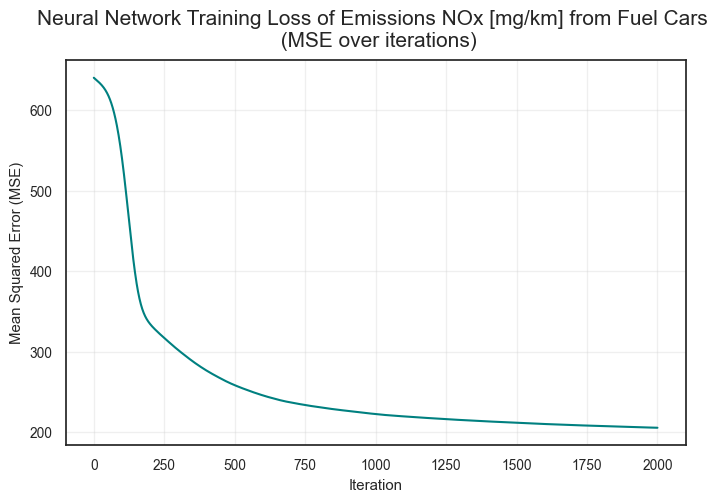

In [ ]:
# Neural Network regression for fuel cars, target variable: Emissions NOx [mg/km]
neural_network_regression("Emissions NOx [mg/km]", data_fuel)

Training RMSE: 0.01876604092186515
Coefficient of determination (R²) on training data: 1.0
Test RMSE: 27.956447589111335
Coefficient of determination (R²) on test data: 0.7186
Validation RMSE: 18.232717513320488
Coefficient of determination (R²) on  validation data: 0.8358


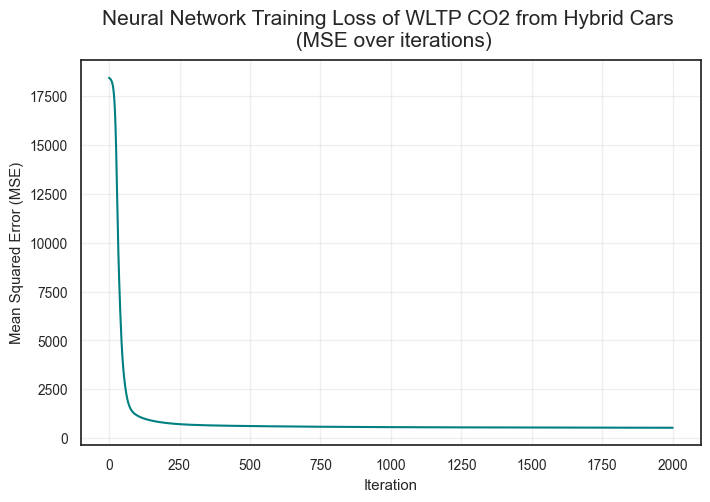

In [ ]:
# Neural Network regression for hybrid cars, target variable: WLTP CO2
neural_network_regression("WLTP CO2", data_hybrid)

Training RMSE: 0.0007698216317201948
Coefficient of determination (R²) on training data: 1.0
Test RMSE: 4.805397664280229
Coefficient of determination (R²) on test data: 0.4879
Validation RMSE: 8.278575248265849
Coefficient of determination (R²) on  validation data: 0.3113


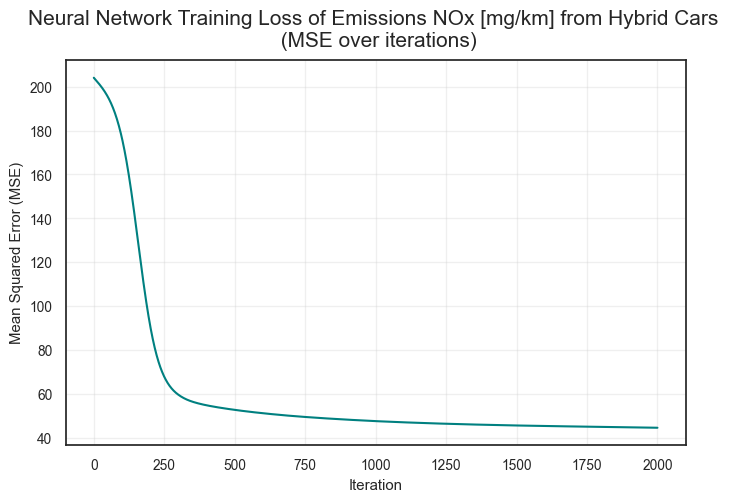

In [ ]:
# Neural Network regression for hybrid cars, target variable: Emissions NOx [mg/km]
neural_network_regression("Emissions NOx [mg/km]", data_hybrid)

In [ ]:
# #Examine weights from the NNR
# import io, contextlib

# buf = io.StringIO()
# with contextlib.redirect_stdout(buf):  # hide print outputs
#     res = neural_network_regression("WLTP CO2", data_fuel);

# # from your Regressor() output
# W0 = res["W0"]                    # shape: [n_features, H]
# features = res["features"]
# imp = np.mean(np.abs(W0), axis=1)

# print("W0 shape:", W0.shape)
# print("Number of features:", len(features))

# # Ensure they match in length
# min_len = min(len(features), len(imp))
# features = features[:min_len]
# imp = imp[:min_len]

# imp_df = pd.DataFrame({"Feature": features, "Importance": imp})
# imp_df = imp_df.sort_values(by="Importance", ascending=True)



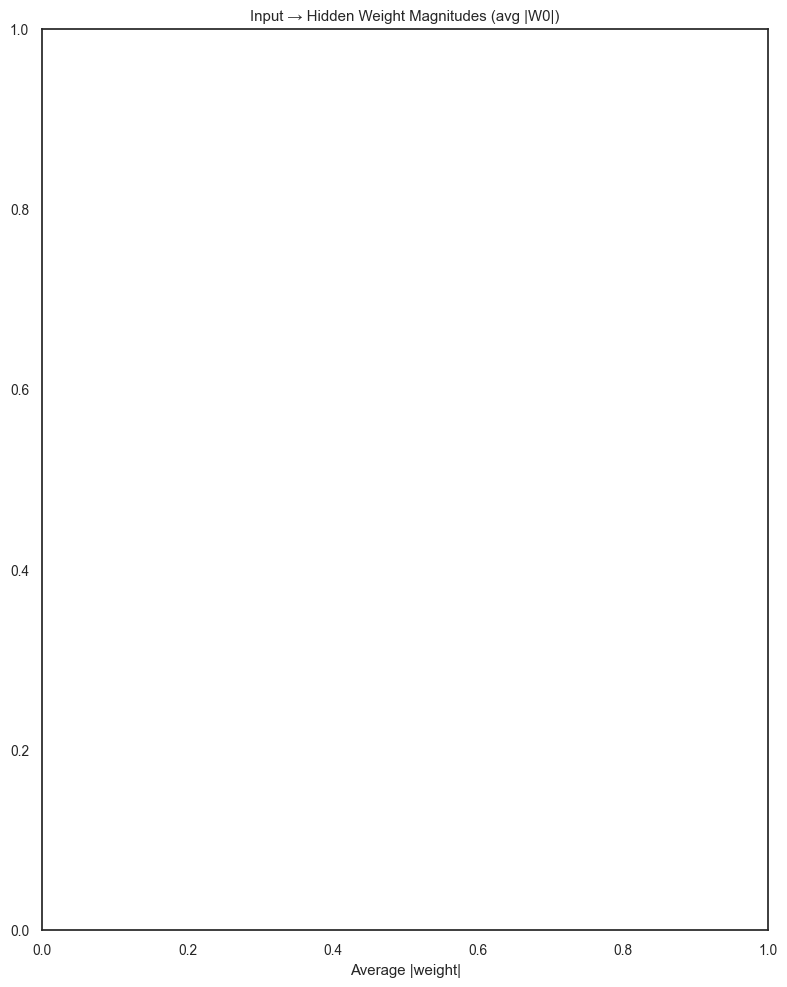

In [ ]:
# importance = average absolute incoming weight to hidden layer
plt.figure(figsize=(8, 10))
#plt.barh(imp_df["Feature"], imp_df["Importance"])
plt.title("Input → Hidden Weight Magnitudes (avg |W0|)")
plt.xlabel("Average |weight|")
plt.tight_layout()
plt.show()

### Neural Network Regression - 3 Layers

Training RMSE: 15.622564437897724
Coefficient of determination (R²) on training data: 0.92
Test RMSE: 15.850467231513218
Coefficient of determination (R²) on test data: 0.888
Validation RMSE: 18.690134370355924
Coefficient of determination (R²) on  validation data: 0.904


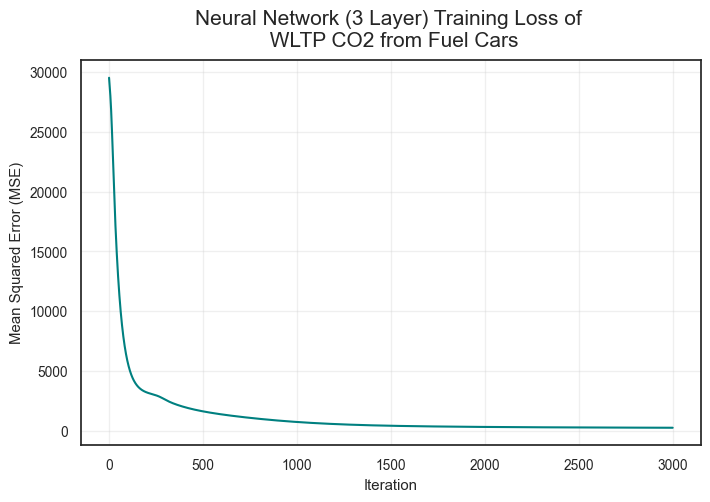

In [ ]:
# Reusable function for Neural Network regression task - 2 hidden layer NN
def neural_network_regression_2hidden(target: str, data: pd.DataFrame, random_state: int = 42):
    assert target in data.columns, f"Target '{target}' not in dataframe."

    splits = data_split(target, data)

    X_train = splits["X_train"]
    X_val   = splits["X_val"]
    X_test  = splits["X_test"]
    y_train = splits["y_train"]   
    y_val   = splits["y_val"]
    y_test  = splits["y_test"]      

    # Flatten target arrays
    y_train = y_train.values.reshape(-1, 1)
    y_val   = y_val.values.reshape(-1, 1)
    y_test  = y_test.values.reshape(-1, 1)

    # scaler = StandardScaler()
    # X_train_scaled = scaler.fit_transform(X_train)
    # X_test_scaled = scaler.transform(X_test)
    # X_val_scaled = scaler.transform(X_val)

    # Define NN dimensions
    N = len(y_train) # number of samples
    D_in = X_train.shape[1] # number of features
    D_out = 1 # number of outputs
    H1 = 30 # number of hidden neurons in hidden layer 1
    H2 = 20 # number of hidden neurons in hidden layer 2

    # -- Initialize weights
    # Layer 1: input -> hidden1
    W0 = normal(0, 0.1, size=(D_in, H1))
    b0 = np.zeros((1, H1))

    # Layer 2: hidden1 -> hidden2
    W1 = normal(0, 0.1, size=(H1, H2))
    b1 = np.zeros((1, H2))

    # Output: hidden2 -> output
    W2 = normal(0, 0.1, size=(H2, D_out))
    b2 = np.zeros((1, D_out))
    
    # Training loop
    eta = 0.0003

    loss_history = []
    for i in range(3001):
        # ---- forward pass ----
        ## Layer 1
        z1 = X_train.dot(W0) + b0
        z1 = np.clip(z1, -500, 500) 
        a1 = 1.0 / (1.0 + np.exp(-z1)) # sigmoid

        # Layer 2
        z2 = a1.dot(W1) + b1
        z2 = np.clip(z2, -500, 500)
        a2 = 1.0 / (1.0 + np.exp(-z2)) # sigmoid

        # Output (linear)
        y_hat = a2.dot(W2) + b2

        # Loss (MSE)
        Loss = np.mean((y_hat - y_train) ** 2)
        loss_history.append(float(Loss))

        # ---- backward pass ----
        # dLoss/dy_hat = 2*(y_hat - y) / N
        dy = (2.0 / N) * (y_hat - y_train)

        # Gradients for output layer (a2 -> y_hat)
        dW2 = a2.T.dot(dy)     
        db2 = np.sum(dy, axis=0, keepdims=True) 

        # Backprop into hidden2
        da2 = dy.dot(W2.T)                        
        dz2 = da2 * a2 * (1.0 - a2)               
        dW1 = a1.T.dot(dz2)                       
        db1 = np.sum(dz2, axis=0, keepdims=True)  

        # Backprop into hidden1
        da1 = dz2.dot(W1.T)                       
        dz1 = da1 * a1 * (1.0 - a1)               
        dW0 = X_train.T.dot(dz1)           
        db0 = np.sum(dz1, axis=0, keepdims=True) 

        # ---- update parameters ----
        W2 -= eta * dW2
        b2 -= eta * db2
        W1 -= eta * dW1
        b1 -= eta * db1
        W0 -= eta * dW0
        b0 -= eta * db0

    # # Evaluate
    # z1 = X_train_scaled.dot(W0)
    # z1 = np.clip(z1, -500, 500)
    # a1 = 1 / (1 + np.exp(-z1))
    # y_pred = a1.dot(W2)

    # Evaluate on training set
    z1_ = X_train.dot(W0) + b0
    z1_ = np.clip(z1_, -500, 500)
    a1_ = 1.0 / (1.0 + np.exp(-z1_))
    
    z2_ = a1_.dot(W1) + b1
    z2_ = np.clip(z2_, -500, 500)
    a2_ = 1.0 / (1.0 + np.exp(-z2_))
    
    y_pred = a2_.dot(W2) + b2

    # MSE and RMSE on training data
    print('Training RMSE:', np.sqrt(mean_squared_error(y_train, y_pred)))
    print('Coefficient of determination (R²) on training data:', round(r2_score(y_train, y_pred),4))

    # Evaluate on test set
    z1_ = X_test.dot(W0) + b0
    z1_ = np.clip(z1_, -500, 500)
    a1_ = 1.0 / (1.0 + np.exp(-z1_))
    z2_ = a1_.dot(W1) + b1
    z2_ = np.clip(z2_, -500, 500)
    a2_ = 1.0 / (1.0 + np.exp(-z2_))
    y_test_pred = a2_.dot(W2) + b2

    print('Test RMSE:', np.sqrt(mean_squared_error(y_test, y_test_pred)))
    print('Coefficient of determination (R²) on test data:', round(r2_score(y_test, y_test_pred),4))

    # Evaluate on validation set
    z1_ = X_val.dot(W0) + b0
    z1_ = np.clip(z1_, -500, 500)
    a1_ = 1.0 / (1.0 + np.exp(-z1_))
    z2_ = a1_.dot(W1) + b1
    z2_ = np.clip(z2_, -500, 500)
    a2_ = 1.0 / (1.0 + np.exp(-z2_))
    y_val_pred = a2_.dot(W2) + b2
    
    print('Validation RMSE:', np.sqrt(mean_squared_error(y_val, y_val_pred)))
    print('Coefficient of determination (R²) on  validation data:', round(r2_score(y_val, y_val_pred),4))


    # Auto labeling based on Fuel Type column
    if data["Fuel Type"].isin(fuel_types).any():
        data_label = "Fuel Cars"
    elif data["Fuel Type"].isin(hybrid_types).any():
        data_label = "Hybrid Cars"
    else:
        data_label = "Dataset"

    #Visualise the MSE
    plt.figure(figsize=(8,5))
    plt.plot(loss_history, color='teal')
    plt.title(f"Neural Network (3 Layer) Training Loss of \n {target} from {data_label}",
              fontsize = 15, pad = 10)
    plt.xlabel("Iteration")
    plt.ylabel("Mean Squared Error (MSE)")
    plt.grid(alpha=0.3)
    plt.show()

    # # Return the weights and features of the model
    # return{
    #     "features": features,
    #     "W0": W0
    #     }

# Neural Network regression for fuel cars, target variable: WLTP CO2
neural_network_regression_2hidden("WLTP CO2", data_fuel)

Training RMSE: 15.393607895371947
Coefficient of determination (R²) on training data: 0.0338
Test RMSE: 12.28769373326525
Coefficient of determination (R²) on test data: -0.0088
Validation RMSE: 12.82621176054791
Coefficient of determination (R²) on  validation data: 0.0358


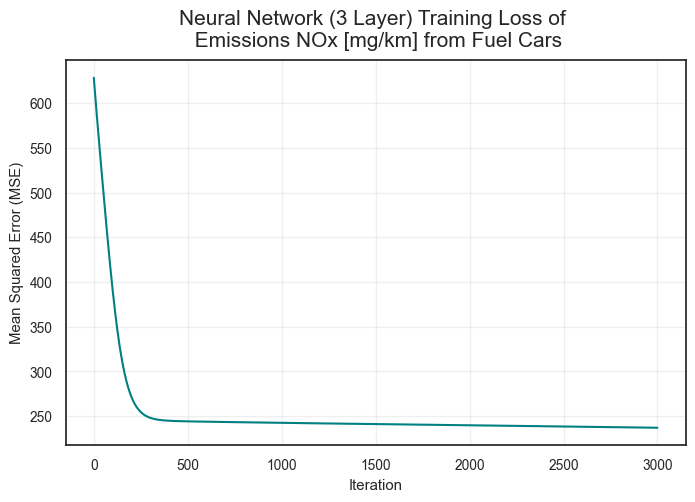

In [ ]:
# NN Regression (2 hidden layers), Emissions NOx from Fuel cars
neural_network_regression_2hidden("Emissions NOx [mg/km]", data_fuel)

Training RMSE: 35.42839109030671
Coefficient of determination (R²) on training data: 0.5719
Test RMSE: 32.62246511055373
Coefficient of determination (R²) on test data: 0.6169
Validation RMSE: 32.63765510527334
Coefficient of determination (R²) on  validation data: 0.4737


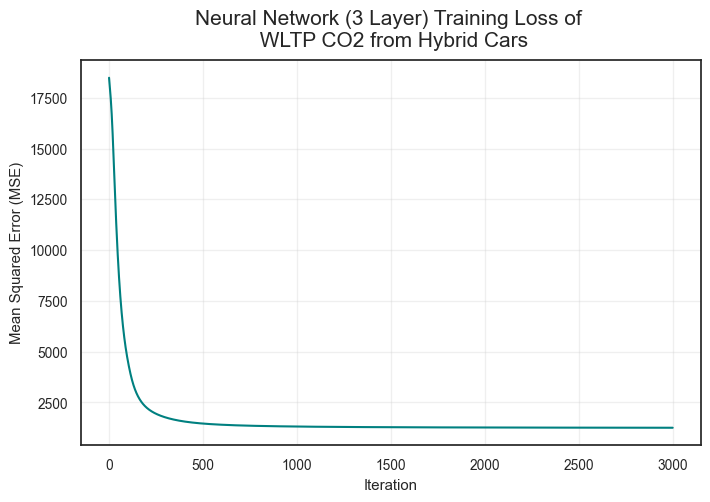

In [ ]:
# NN Regression (2 hidden layers), CO2 emissions from Hybrid cars
neural_network_regression_2hidden("WLTP CO2", data_hybrid)

Training RMSE: 8.005424250010037
Coefficient of determination (R²) on training data: 0.1486
Test RMSE: 5.914581063728446
Coefficient of determination (R²) on test data: 0.2243
Validation RMSE: 9.415363072073598
Coefficient of determination (R²) on  validation data: 0.1092


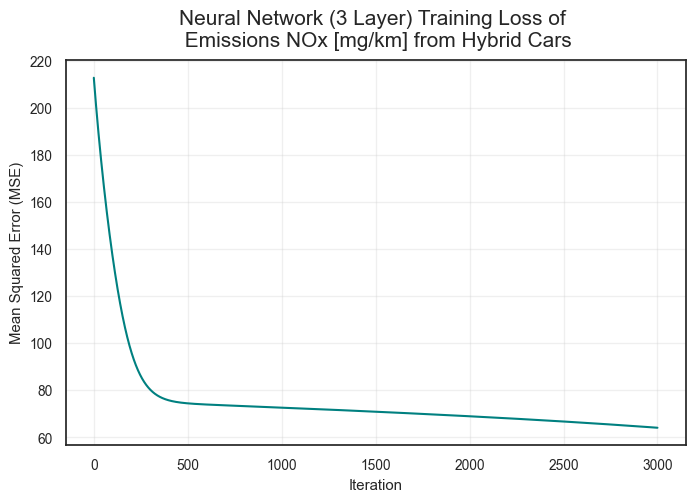

In [ ]:
# NN Regression (2 hidden layers), Emissions NOx from Hybrid cars
neural_network_regression_2hidden("Emissions NOx [mg/km]", data_hybrid)

### Neural Network Regression - 4 Layers

Training RMSE: 138.1645823541116
Coefficient of determination (R²) on training data: -5.2572
Test RMSE: 138.67875772052057
Coefficient of determination (R²) on test data: -7.5738
Validation RMSE: 146.49132268610106
Coefficient of determination (R²) on  validation data: -4.8955


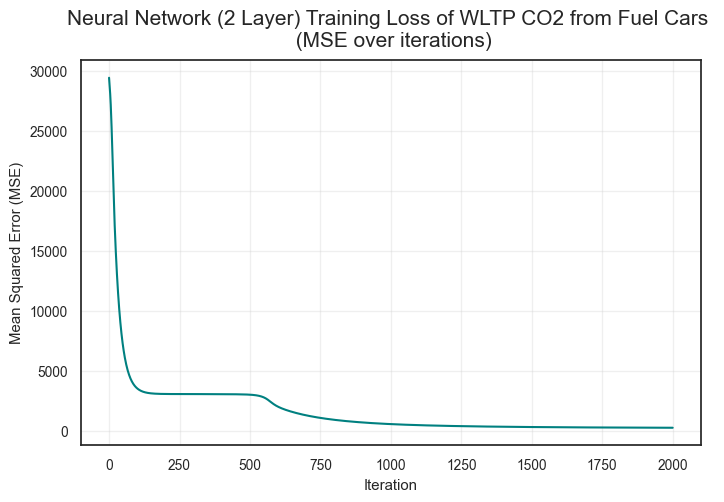

In [ ]:
# Reusable function for Neural Network regression task - 3 hidden layer NN

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def neural_network_regression_3hidden(target: str, data: pd.DataFrame, random_state: int = 42):
    assert target in data.columns, f"Target '{target}' not in dataframe."

    # Perform data splitting
    splits = data_split(target, data)   
    
    X_train = splits["X_train"]
    X_val   = splits["X_val"]
    X_test  = splits["X_test"]
    y_train = splits["y_train"]   
    y_val   = splits["y_val"]
    y_test  = splits["y_test"]
    
    # Flatten target arrays
    y_train = y_train.values.reshape(-1, 1)
    y_val   = y_val.values.reshape(-1, 1)
    y_test  = y_test.values.reshape(-1, 1)


    # Define NN dimensions
    N = len(y_train) # number of samples
    D_in = X_train.shape[1] # number of features
    D_out = 1 # number of outputs
    
    H1 = 40 # number of hidden neurons in hidden layer 1
    H2 = 30 # number of hidden neurons in hidden layer 2
    H3 = 20 # number of hidden neurons in hidden layer 3

    # -- Initialize weights
    # Layer 1: input -> hidden1
    W0 = normal(0, 0.1, size=(D_in, H1))
    b0 = np.zeros((1, H1))

    # Layer 2: hidden1 -> hidden2
    W1 = normal(0, 0.1, size=(H1, H2))
    b1 = np.zeros((1, H2))

    # Layer 3: hidden2 -> hidden3
    W2 = normal(0, 0.1, size=(H2, H3))
    b2 = np.zeros((1, H3))

    # Output: hidden3 -> output
    W3 = normal(0, 0.1, size=(H3, D_out))
    b3 = np.zeros((1, D_out))
    
    # Training loop
    eta = 0.0005

    loss_history = []
    for i in range(2001):
        # ---- forward pass ----
        ## Layer 1
        z1 = X_train.dot(W0) + b0
        z1 = np.clip(z1, -500, 500) 
        a1 = 1 / (1 + np.exp(-z1)) # sigmoid

        # Layer 2
        z2 = a1.dot(W1) + b1
        z2 = np.clip(z2, -500, 500)
        a2 = 1 / (1 + np.exp(-z2)) # sigmoid

        # Layer 3
        z3 = a2.dot(W2) + b2
        z3 = np.clip(z3, -500, 500)
        a3 = 1 / (1 + np.exp(-z3)) # sigmoid

        # Output (linear)
        y_hat = a3.dot(W3) + b3

        # Loss (MSE)
        Loss = np.mean((y_hat - y_train) ** 2)
        loss_history.append(float(Loss))


        # ---- backward pass ----
        dy = (2.0 / N) * (y_hat - y_train)

        # Gradients for output layer (a3 -> y_hat)
        dW3 = a3.T.dot(dy)       
        db3 = np.sum(dy, axis=0, keepdims=True)

        # Backprop into hidden3
        da3 = dy.dot(W3.T)
        dz3 = da3 * a3 * (1 - a3)
        dW2 = a2.T.dot(dz3)
        db2 = np.sum(dz3, axis=0, keepdims=True)
        
        # Backprop into hidden2
        da2 = dz3.dot(W2.T)
        dz2 = da2 * a2 * (1 - a2)
        dW1 = a1.T.dot(dz2)
        db1 = np.sum(dz2, axis=0, keepdims=True)
        
        # Backprop into hidden1
        da1 = dz2.dot(W1.T)
        dz1 = da1 * a1 * (1 - a1)
        dW0 = X_train.T.dot(dz1)
        db0 = np.sum(dz1, axis=0, keepdims=True)
 
        # ---- update parameters ----
        W3 -= eta * dW3
        b3 -= eta * db3
        
        W2 -= eta * dW2
        b2 -= eta * db2
        
        W1 -= eta * dW1
        b1 -= eta * db1
        
        W0 -= eta * dW0
        b0 -= eta * db0

    # Evaluate on training set
    def predict(X):
        z1 = X.dot(W0) + b0
        z1_ = np.clip(z1, -500, 500)
        a1 = 1.0 / (1.0 + np.exp(-z1_))
        
        z2 = a1.dot(W1) + b1
        z2_ = np.clip(z2, -500, 500)
        a2 = np.clip(z2_, -500, 500)
        
        z3 = a2.dot(W2) + b2
        z3_ = np.clip(z3, -500, 500)
        a3 = 1.0 / (1.0 + np.exp(-z3_))

        return a3.dot(W3) + b3

    
    # z1 = X_train_scaled.dot(W0) + b0
    # z1_ = np.clip(z1, -500, 500)
    # a1 = 1.0 / (1.0 + np.exp(-z1_))
        
    # z2 = a1.dot(W1) + b1
    # z2_ = np.clip(z2, -500, 500)
    # a2 = np.clip(z2_, -500, 500)
    
    # z3 = a2.dot(W2) + b2
    # z3_ = np.clip(z3, -500, 500)
    # a3 = 1.0 / (1.0 + np.exp(-z3_))
    # y_train_pred = a3.dot(W3) + b3

    # MSE and RMSE on training data
    y_train_pred = predict(X_train)
    print('Training RMSE:', np.sqrt(mean_squared_error(y_train, y_train_pred)))
    print('Coefficient of determination (R²) on training data:', round(r2_score(y_train, y_train_pred),4))

    # Evaluate on test set
    y_test_pred = predict(X_test)
    print('Test RMSE:', np.sqrt(mean_squared_error(y_test, y_test_pred)))
    print('Coefficient of determination (R²) on test data:', round(r2_score(y_test, y_test_pred),4))

    # Evaluate on validation set
    y_val_pred = predict(X_val)
    print('Validation RMSE:', np.sqrt(mean_squared_error(y_val, y_val_pred)))
    print('Coefficient of determination (R²) on  validation data:', round(r2_score(y_val, y_val_pred),4))


    # Auto labeling based on Fuel Type column
    if data["Fuel Type"].isin(fuel_types).any():
        data_label = "Fuel Cars"
    elif data["Fuel Type"].isin(hybrid_types).any():
        data_label = "Hybrid Cars"
    else:
        data_label = "Dataset"


    #Visualise the MSE
    plt.figure(figsize=(8,5))
    plt.plot(loss_history, color='teal')
    plt.title(f"Neural Network (2 Layer) Training Loss of {target} from {data_label} \n (MSE over iterations)",
              fontsize = 15, pad = 10)
    plt.xlabel("Iteration")
    plt.ylabel("Mean Squared Error (MSE)")
    plt.grid(alpha=0.3)
    plt.show()

    # # Return the weights and features of the model
    # return{
    #     "features": features,
    #     "W0": W0
    #     }

# Neural Network regression for fuel cars, target variable: WLTP CO2
neural_network_regression_3hidden("WLTP CO2", data_fuel)

Training RMSE: 15.601972032883996
Coefficient of determination (R²) on training data: 0.0075
Test RMSE: 12.140231683389397
Coefficient of determination (R²) on test data: 0.0153
Validation RMSE: 12.977859002448692
Coefficient of determination (R²) on  validation data: 0.0129


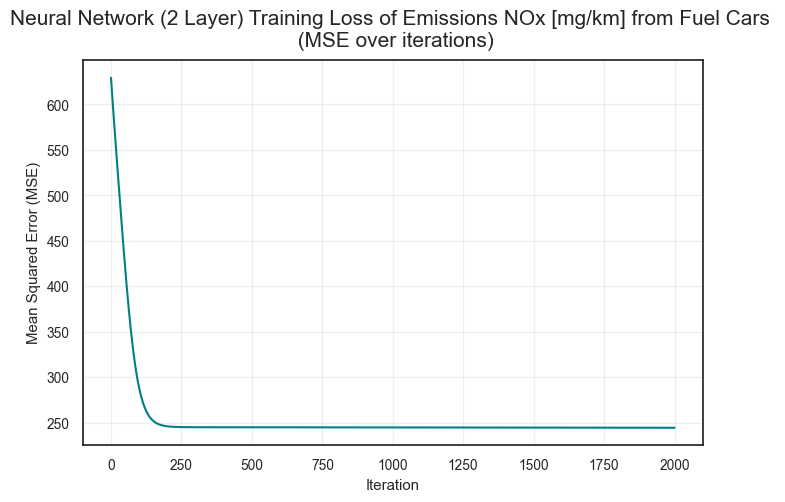

In [ ]:
neural_network_regression_3hidden("Emissions NOx [mg/km]", data_fuel)

Training RMSE: 35.56435477602406
Coefficient of determination (R²) on training data: 0.5687
Test RMSE: 32.2759250197809
Coefficient of determination (R²) on test data: 0.625
Validation RMSE: 32.67101399065757
Coefficient of determination (R²) on  validation data: 0.4726


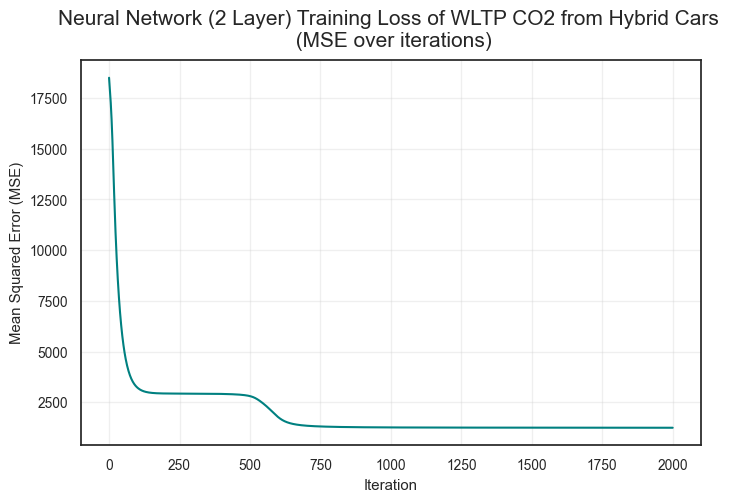

In [ ]:
neural_network_regression_3hidden("WLTP CO2", data_hybrid)

Training RMSE: 8.549650805680743
Coefficient of determination (R²) on training data: 0.0289
Test RMSE: 6.486216803484162
Coefficient of determination (R²) on test data: 0.0671
Validation RMSE: 9.968267522196147
Coefficient of determination (R²) on  validation data: 0.0015


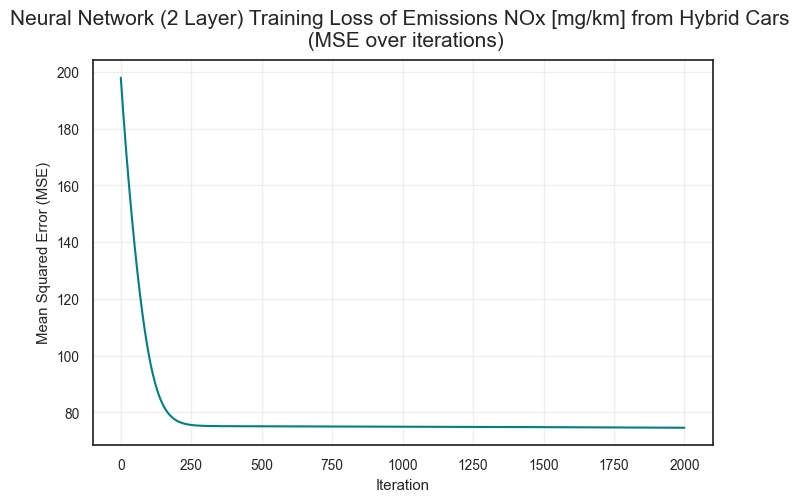

In [ ]:
neural_network_regression_3hidden("Emissions NOx [mg/km]", data_hybrid)

# References
- European Environment Agency, 2023, 'Greenhouse Gas Emissions from Transport in Europe.', _EEA Report No. 23/2023_, Publications Office of the European Union.

- Intergovernmental Panel on Climate Change (IPCC), 2022, 'Climate Change 2022: Mitigation of Climate Change', _Contribution of Working Group III to the Sixth Assessment Report of the IPCC_, Cambridge University Press.

- UK Vehicle Certification Agency, 2024, _Fuel Consumption and Emission Data Tables: Car Fuel and CO₂ Information. Department for Transport_, viewed 29 September 2025, <https://www.vehicle-certification-agency.gov.uk/>

- World Health Organization, 2021, _WHO Global Air Quality Guidelines: Particulate Matter, Ozone, Nitrogen Dioxide, Sulfur Dioxide and Carbon Monoxide_, Geneva: WHO.

- U.S. Environmental Protection Agency (EPA), 2023, _Nitrogen Oxides (NOₓ) Pollution_, EPA.

- European Environment Agency (EEA), 2022, _Air Pollution Sources — Volatile Organic Compounds (VOCs)_, EEA Report

- Veza, Ibham et al, 2023, 'Electric Vehicle (EV) and Driving Towards Sustainability: Comparison between EV, HEV, PHEV, and ICE Vehicles to Achieve Net Zero Emissions by 2050 from EV', _Alexandria Engineering Journal_, vol. 82, pp. 459–467, DOI.10.1016/j.aej.2023.10.020

